<a href="https://colab.research.google.com/github/Jenn-mawia/openIMIS-hackathon/blob/main/Jenipher_Mawia_228853_data_mining_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FRAUD DETECTION ON HEALTH INSURANCE CLAIMS**



# 1.0 Introduction

## Background
When a patient with medical insurance visits a hospital or clinic, the provider bills the
insurer rather than the patient, and the insurer checks the invoice and settles some or all
of it. Health insurance in Kenya is expanding rapidly, and the volume of claims flowing
through this process is growing with it. Some proportion of those claims are not honest: **a
provider may bill for a service never delivered, inflate the cost of one that was, submit the
same invoice twice, or record a treatment date that does not match when the patient was
actually seen**. Individually these amounts are modest, but collectively they represent a
substantial and largely invisible drain on the funds available to pay for genuine care. **The
conventional defence is manual audit**, which works but does not scale — an audit team of fixed
size reviewing a claim volume that grows every year inspects a shrinking fraction of the
total, **and the claims never examined are not a low-risk sample but simply the ones no one had
time to reach**. This creates a clear role for automated screening: if a system could read every
claim and rank them by how unusual they are, auditors could start with the most anomalous
rather than an arbitrary selection. The goal is not to replace human judgement but to direct
it, so that limited review capacity is spent where the risk is concentrated.

## Research Problem
The obvious way to build such a system is to perform supervised learning - a method that involves showing a computer many confirmed examples of fraud and many confirmed examples of legitimate claims and let it learn the difference. This option is not available here because the dataset records what was invoiced, what was settled and what the audit outcome was, but no claim carries a verified "fraudulent" or "legitimate" tag. **The absence in fraud label is normal rather than a defect: fraud is only ever labelled after investigation**, investigation is expensive and most claims are never investigated, so insurers hold vast records of claims and almost none of which ones were dishonest.

**The research problem is therefore methodological — how can irregular claims be identified when there are no examples of irregular claims to learn from?**

This study takes two routes.
- **The first is unsupervised anomaly detection**, which learns what ordinary claiming behaviour looks like from the data itself and flags departures from it without ever being told what fraud is.
- **The second is a proxy indicator:** when an insurer settles a claim for substantially less than was invoiced, it has signalled that something did not hold up. That signal is not proof of fraud, since claims are also reduced for innocent reasons such as benefit limits or excluded items, but it is an observable trace of the insurer's own scepticism and can be used to characterise suspicious claims and to check whether the patterns an unsupervised model finds correspond to anything the insurer already treats as problematic.

## Objectives

The general objective of this study is to profile, clean and prepare a large Kenyan health insurance claims dataset so that irregular claims can be identified without relying on confirmed fraud labels.

The specific objectives are:
1. To profile the dataset and remove personally identifying information, so that analysis can proceed without exposing patient identity.
2. To clean the data by resolving inconsistent date formats, mixed currencies, duplicate records and missing values.
3. To explore the data descriptively, establishing what ordinary claiming behaviour looks like across providers, services, benefit categories and time.
4. To explore the data diagnostically, identifying which observable characteristics of a claim are associated with the insurer settling it for less than the amount invoiced.
5. To prepare the resulting dataset for unsupervised anomaly detection by constructing features that capture recognised irregularity signals, including billing inconsistencies and dates that are impossible or implausible.
7. Use an Isolation Forest algorithm to detect fraud in the dataset.

# 2.0 Methodology, Results and Discussion

## Data Description

The dataset used in this study is an operational claims register extracted from the claims management system of a private medical insurance administrator operating in Kenya.

It contains **422,382 individual claim records described by 30 variables**. Each row represents a single claim submitted by a healthcare provider on behalf of an insured member, together with the amount invoiced, the
amount the insurer settled and the administrative outcome of the claim. The records are not survey responses or a sample drawn for research purposes; they are the by-product of routine business operations, captured automatically as claims moved through submission, audit and payment. The extract was filtered on claim audit date, and the audit dates range from **30 August 2018 to 11 December 2025**, though the distribution is heavily concentrated in recent activity: 409,352 claims (96.9%) carry a 2025 date, 11,942 fall in 2024, and fewer than 1,100 records predate 2024.

**Because the data was generated by an operational system rather than collected under controlled conditions, it carries the characteristic imperfections of administrative records: dates stored inconsistently as both text and Excel serial numbers, invoices denominated in six different currencies from, free-text fields with no controlled vocabulary and one column recorded as entirely null**. Personally identifying information was
present in the source file and was removed before analysis.

### Variable description

| # | Variable | Data Type | Description |
|---|----------|------|-------------|
| 1 | POLICY CODE | Categorical (ID) | Identifier of the insurance policy under which the claim falls |
| 2 | PLAN NAME | Categorical | Name of the benefit plan, typically the employer or scheme sponsoring cover (1,203 levels) |
| 3 | MEMBERSHIP NO | Categorical (ID) | Unique member identifier; 103,068 distinct members appear in the data |
| 4 | PATIENT NAME | Text (PII) | Full name of the patient receiving treatment |
| 5 | PRINCIPAL MEMBER | Text (PII) | Full name of the principal policyholder, who may differ from the patient |
| 6 | PAYEE | Categorical | Entity receiving payment, usually the treating facility (2,783 levels) |
| 7 | CLAIM DATE | Date | Date the claim was registered in the system |
| 8 | CLAIM TYPE | Categorical | Care setting: OP (outpatient, 408,525) or IP (inpatient, 13,857) |
| 9 | PAYMENT FROM | Categorical | Funding source: insured, self fund, or indemnity |
| 10 | PROVIDER NAME | Categorical | Facility that delivered the service (1,019 levels) |
| 11 | DOCTOR | Numeric | Attending clinician identifier; entirely null across all 422,382 records |
| 12 | SERVICE | Text | Comma-separated list of all line items billed on the claim; free text, 126,231 distinct values |
| 13 | DIAGNOSIS CODE | Categorical | Internal diagnosis grouping; constant value "OTHERS" wherever populated |
| 14 | DIAGNOSIS | Text | Clinical description of the diagnosis in ICD-10 narrative form (6,358 levels) |
| 15 | INVOICE NUMBER | Categorical (ID) | Provider's invoice reference |
| 16 | CLAIM NO | Categorical (ID) | Insurer's internal claim reference |
| 17 | PROD CURRENCY | Categorical | Currency of the benefit product (KES, UGX, or unspecified) |
| 18 | INVOICE AMOUNT | Numeric | Amount invoiced by the provider, as recorded on the claim |
| 19 | SETTLED AMOUNT | Numeric | Amount the insurer ultimately paid |
| 20 | INV CURRENCY | Categorical | Currency of the invoice (KES, UGX, TZS, USD, RWF, SSP) |
| 21 | INV AMOUNT | Numeric | Invoice amount as captured at entry, before any pre-audit adjustment |
| 22 | PAYABLE AMOUNT | Numeric | Amount assessed as payable; equals SETTLED AMOUNT in 99.3% of records |
| 23 | NOTES | Text | Short processing annotation, e.g. "P", "PAYABLE", "AUTO-BATCH PROCESSED" (595 levels) |
| 24 | GROUP NAME | Categorical | Corporate group or association holding the policy (1,502 levels) |
| 25 | BENEFIT CODE | Categorical | Benefit category the claim was charged against, e.g. OUT-PATIENT, DENTAL, MATERNITY (48 levels) |
| 26 | CLAIM SUB TYPE | Categorical | Finer classification of the claim, e.g. CHRONIC, OPTICAL, EMERGENCY (38 levels) |
| 27 | ICD CODE | Categorical | ICD-10 diagnosis code, e.g. Z00.0, H52.1 (6,454 levels) |
| 28 | CLAIM AUDIT DATE | Date | Date the claim was audited; the field on which this extract was filtered |
| 29 | SERVICE DATE | Date | Date treatment was actually delivered |
| 30 | STATUS | Categorical | Administrative state: PAID (370,318), AUDITED (49,849), CANCELLED (1,772), and four rarer states |

Even before the data is cleaned or analysed, it is important to recognize that there are some **personal identifiers in the data and these need to be handled in order to protect their privacy in accordance with Data Protection Laws**.

> The patient name and principal member names were removed before proceeding further on Microsoft Excel.

### Research design

This study follows an exploratory, quantitative design applied to secondary administrative
data. Because no claim carries a confirmed fraud label, the work is structured not as a
prediction task with a known answer to be recovered, but as a characterisation task: **the aim
is to establish what ordinary claiming behaviour looks like in this book of business** and to
prepare the data so that departures from it can be detected automatically. The analysis
proceeds in five stages
- anonymisation
- cleaning
- exploratory analysis
- feature engineering and model pre-treatment and
- finally building the machine learning model — each of which is described below.

All work was carried out in Python.

### Importing Libraries

In [ ]:
import argparse
import os
import hashlib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest




### Loading and Checking the data

In [ ]:
df = pd.read_csv("data/OVERALL CLAIMS PAID ANALYSIS - AUDIT DATE - 202507-11.csv")

# number of rows and columns
rows, cols = df.shape
print(f"Number of Rows : {rows} \nNumber of Columns : {cols}")


Number of Rows : 422382 
Number of Columns : 28


In [ ]:
# top of the data
df.head()

,POLICY CODE,PLAN NAME,MEMBERSHIP NO,PAYEE,CLAIM DATE,CLAIM TYPE,PAYMENT FROM,PROVIDER NAME,DOCTOR,SERVICE,...,INV AMOUNT,PAYABLE AMOUNT,NOTES,GROUP NAME,BENEFIT CODE,CLAIM SUB TYPE,ICD CODE,CLAIM AUDIT DATE,SERVICE DATE,STATUS
0,KEA1B1/21/PD087/000001/02,SMEC INTERNATIONAL PTY LIMITED,UK09931800,EQUITY AFIA LIMITED (KE),25/11/2025,OP,insured,EQUITY AFIA LIMITED (KE),NaN,LAB TESTS,...,5000.0,5000.0,p,SMEC INTERNATIONAL PTY LIMITED,ANNUAL MEDICAL CHECK-UP,ANNUAL MEDICAL CHECKUP,Z00.0,25/11/2025,28/04/2025,AUDITED
1,TANATHIWSBS/08,TANATHI WATER SERVICES BOARD [STAFF],UK06606100,EQUITY AFIA LIMITED (KE),25/11/2025,OP,insured,EQUITY AFIA LIMITED (KE),NaN,SPECTACLE FRAME,...,15000.0,15000.0,p,TANATHI WATER WORKS DEVELOPMENT AGENCY (STAFF),OPTICAL,OPTICAL,H52.1,25/11/2025,26/06/2025,AUDITED
2,KEA1B1/21/PC514/000001/03,HAND IN HAND EASTERN AFRICA,UK08084802,EQUITY AFIA LIMITED (KE),25/11/2025,OP,insured,EQUITY AFIA LIMITED (KE),NaN,CONSULTANT,...,2900.0,500.0,p,HAND IN HAND EASTERN AFRICA,OUT-PATIENT,OUT-PATIENT,Z51.9,25/11/2025,03/03/2025,AUDITED
3,KEA1B1/21/PC514/000001/03,HAND IN HAND EASTERN AFRICA,UK09899600,EQUITY AFIA LIMITED (KE),25/11/2025,OP,insured,EQUITY AFIA LIMITED (KE),NaN,"CONSULTANT,DRUGS",...,5230.0,5230.0,p,HAND IN HAND EASTERN AFRICA,OUT-PATIENT,OUT-PATIENT,Z51.9,25/11/2025,03/03/2025,AUDITED
4,KEA1B1/21/PC514/000001/03,HAND IN HAND EASTERN AFRICA,UK08073000,EQUITY AFIA LIMITED (KE),25/11/2025,OP,insured,EQUITY AFIA LIMITED (KE),NaN,"CONSULTANT,DRUGS",...,3050.0,3050.0,p,HAND IN HAND EASTERN AFRICA,OUT-PATIENT,OUT-PATIENT,Z51.9,25/11/2025,04/03/2025,AUDITED


In [ ]:
# bottom of the data
df.tail()

,POLICY CODE,PLAN NAME,MEMBERSHIP NO,PAYEE,CLAIM DATE,CLAIM TYPE,PAYMENT FROM,PROVIDER NAME,DOCTOR,SERVICE,...,INV AMOUNT,PAYABLE AMOUNT,NOTES,GROUP NAME,BENEFIT CODE,CLAIM SUB TYPE,ICD CODE,CLAIM AUDIT DATE,SERVICE DATE,STATUS
422377,KEHPCA/01,KENYA HOSPICE AND PALLIATIVE CARE ASSOC,7224095-00,NAIROBI HOSPITAL (10468KE),30/08/2018,IP,insured,NAIROBI HOSPITAL (10468KE),NaN,ADMISSION FEES,...,6400.0,6400.0,p,KENYA HOSPICE AND PALLIATIVE CARE ASSOC,IN-PATIENT,GENERAL HOSPITALIZATION,D05,30/08/2018,01/12/2016,PAID
422378,BHANJIZS/02,AFYAIMARA SENIOR MEDICAL COVER,8183333-00,THE AGA KHAN UNIVERSITY HOSPITALNAIROBI (10461KE),15/05/2019,OP,insured,THE AGA KHAN UNIVERSITY HOSPITALNAIROBI (10461KE),NaN,PHYSIOTHERAPY,...,6200.0,6200.0,PAYABLE,NaN,OUT-PATIENT,OUT-PATIENT,M54.4,15/05/2019,31/12/2016,PAID
422379,NAIVAS/02,NAIVAS LIMITED,8551332-02,DR DONALD P. OYATSI (10825KE),06/05/2019,OP,self fund,DR DONALD P. OYATSI (10825KE),NaN,CONSULTANT,...,3000.0,3000.0,pay,NAIVAS LIMITED,OUT-PATIENT,OUT-PATIENT,G40.6,43621,14/03/2018,PAID
422380,EABL/02,EAST AFRICA BREWERIES LTD STAFF MEDICAL,02108324-00,NAIROBI HOSPITAL (10468KE),31/01/2019,OP,self fund,NAIROBI HOSPITAL (10468KE),NaN,LAB TESTS,...,9800.0,9800.0,PAY,EAST AFRICA BREWERIES LTD STAFF MEDICAL,OUT-PATIENT,OUT-PATIENT,Z36.9,31/01/2019,08/10/2016,PAID
422381,BASFEAL/01,BASF EAST AFRICA LIMITED,02175146-03,DR B.J. NATHWANI (77330KE),19/01/2019,OP,self fund,DR B.J. NATHWANI (77330KE),NaN,CONSULTANT,...,1200.0,1200.0,P,BASF EAST AFRICA LIMITED,DENTAL,DENTAL,K02,19/01/2019,10/09/2016,PAID


In [ ]:
# check the datatypes in the dataset
df.dtypes

POLICY CODE          object
PLAN NAME            object
MEMBERSHIP NO        object
PAYEE                object
CLAIM DATE           object
CLAIM TYPE           object
PAYMENT FROM         object
PROVIDER NAME        object
DOCTOR              float64
SERVICE              object
DIAGNOSIS CODE       object
DIAGNOSIS            object
INVOICE NUMBER       object
CLAIM NO             object
PROD CURRENCY        object
INVOICE AMOUNT      float64
SETTLED AMOUNT      float64
INV CURRENCY         object
INV AMOUNT          float64
PAYABLE AMOUNT      float64
NOTES                object
GROUP NAME           object
BENEFIT CODE         object
CLAIM SUB TYPE       object
ICD CODE             object
CLAIM AUDIT DATE     object
SERVICE DATE         object
STATUS               object
dtype: object

NUMERIC COLUMNS: DOCTOR, INVOICE AMOUNT, SETTLED AMOUNT, INV AMOUNT, PAYABLE AMOUNT

NON-NUMERIC COLUMNS: 'POLICY CODE', 'PLAN NAME', 'MEMBERSHIP NO', 'PAYEE', 'CLAIM DATE', 'CLAIM TYPE', 'PAYMENT FROM', 'PROVIDER NAME', 'SERVICE', 'DIAGNOSIS CODE', 'DIAGNOSIS','INVOICE NUMBER', 'CLAIM NO', 'PROD CURRENCY', 'INV CURRENCY', 'NOTES', 'GROUP NAME', 'BENEFIT CODE', 'CLAIM SUB TYPE', 'ICD CODE', 'CLAIM AUDIT DATE', 'SERVICE DATE', 'STATUS'.

In [ ]:
# general information about the data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422382 entries, 0 to 422381
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   POLICY CODE       422382 non-null  object 
 1   PLAN NAME         422055 non-null  object 
 2   MEMBERSHIP NO     422055 non-null  object 
 3   PAYEE             422381 non-null  object 
 4   CLAIM DATE        422382 non-null  object 
 5   CLAIM TYPE        422382 non-null  object 
 6   PAYMENT FROM      422382 non-null  object 
 7   PROVIDER NAME     422382 non-null  object 
 8   DOCTOR            0 non-null       float64
 9   SERVICE           422382 non-null  object 
 10  DIAGNOSIS CODE    413046 non-null  object 
 11  DIAGNOSIS         417436 non-null  object 
 12  INVOICE NUMBER    422382 non-null  object 
 13  CLAIM NO          422382 non-null  object 
 14  PROD CURRENCY     422382 non-null  object 
 15  INVOICE AMOUNT    422382 non-null  float64
 16  SETTLED AMOUNT    42

In [ ]:
# check for missing data
nulls = df.isnull().sum()
nulls[nulls > 0].sort_values(ascending=False)

DOCTOR            422382
GROUP NAME         30583
DIAGNOSIS CODE      9336
DIAGNOSIS           4946
ICD CODE            4946
PLAN NAME            327
MEMBERSHIP NO        327
NOTES                 31
PAYEE                  1
BENEFIT CODE           1
dtype: int64

**Observations:**
- `DOCTOR` is 100% null — drop or ignore in features.
- `DIAGNOSIS CODE` has ~9K nulls and `ICD CODE` and `DIAGNOSIS` have ~5K nulls.

### Anonymize the data

The source extract contained direct identifiers, including patient names, principal member
names and policy references, alongside clinical diagnosis information. Because health data is
sensitive and re-identification is possible even from indirect combinations of fields, the
data was anonymised before any analytical work began rather than afterwards. **Direct name
fields were removed** outright. Identifiers that remain analytically necessary — **the membership
number**, which is required to count claims per member — **were replaced with irreversible hashed
values**, preserving the ability to group records by member without exposing who that member is.

> No analysis in this study requires knowing the identity of any individual and none was
retained.

Drop direct identifiers, hash the membership number so per-member patterns stay trackable.

In [ ]:
# need to drop direct identifier columns(membership number, claim number, etc.)
# and quasi identifier columns (date of birth, address, etc.) to protect patient privacy.

personal_info_cols = ["MEMBERSHIP NO", "INVOICE NUMBER", "CLAIM NO", "POLICY CODE"]
df[personal_info_cols].sample(10)

,MEMBERSHIP NO,INVOICE NUMBER,CLAIM NO,POLICY CODE
295121,UK06534706,1210696955#000,RC23070211974,KEA1B1/20/PB489/000001/04
87796,UK10408003,29911#000,RC23092811675,KEA1B1/20/PB528/000001/04
255862,OK12869602,OPR83279/23#000,RC23072010946,KEA1B1/22/PE144/000001/01
380829,UK03241403,UH281353102_2#000,RC23052413735,KEA1B1/18/PA666/000001/05
317884,OK13967003,INV1482646#000,RC23062512089,KEA1B1/23/PE416/000001/01
144731,UK08949000,O293921#000,RC23090512053,KEA1B1/21/PB635/000183/03
410650,OK13217700,OPT-15449#000,RC22120310262,KEA1B1/22/PD606/000001/01
289989,UK10587403,O1325644#000,RC23070810935,KEA1B1/21/PD307/000001/02
46689,UK10471602,IHT/OB66552/23#000,RC23102113542,KEA1B1/21/PC514/000001/03
233519,UK06791203,NC29580580_1#000,RC23082310151,KEA1B1/20/PB544/000001/04


In [ ]:
# Drop direct identifiers
# df = df.drop(columns=["PATIENT NAME", "PRINCIPAL MEMBER"])

# Hash MEMBERSHIP NO, INVOICE NO, CLAIM NO — keeps per-member grouping possible without exposing the real ID
df['hash_membership_no'] = df['MEMBERSHIP NO'].apply(lambda x: hashlib.sha256(str(x).encode()).hexdigest()[:12] if pd.notna(x) else "unknown")
df['hash_invoice_no'] = df['INVOICE NUMBER'].apply(lambda x: hashlib.sha256(str(x).encode()).hexdigest()[:12] if pd.notna(x) else "unknown")    #preserves duplicate detection, prevents re-identification
df['hash_claim_no'] = df['CLAIM NO'].apply(lambda x: hashlib.sha256(str(x).encode()).hexdigest()[:12] if pd.notna(x) else "unknown")
df['hash_policy_code'] = df['POLICY CODE'].apply(lambda x: hashlib.sha256(str(x).encode()).hexdigest()[:12] if pd.notna(x) else "unknown")

df = df.drop(columns=["MEMBERSHIP NO", "INVOICE NUMBER", "CLAIM NO", "POLICY CODE"])

print(f"Anonymised DataFrame shape: {df.shape}")
print(f"Sample of anonymised DataFrame:\n{df[['hash_claim_no', 'hash_invoice_no', 'hash_membership_no', 'hash_policy_code']].sample(10)}")

Anonymised DataFrame shape: (422382, 28)
Sample of anonymised DataFrame:
       hash_claim_no hash_invoice_no hash_membership_no hash_policy_code
3796    f629688eec31    f3fc10635fd4       79f68d4d8990     8f5eabb66f42
183060  e53f23342cc2    4f0f8f281e9f       1ad2de4fc9ad     eaf06580fc39
289401  a52c549244a6    0882c3597f25       86112a0dcb0c     9a14538d7825
101495  505b524e1077    b21405b7aa00       19c856ed881d     497ed391624e
91865   c86298aa9849    58373b3d6e55       bda8bb2e9641     ecf7877818eb
190564  8395cefccbbd    1509ca8faaac       4bd97fc213b8     2864d4957f26
63027   ae4a500f1d3d    0bf2194cb5b8       08a37b286e7e     03f5ba938f21
31226   974540ae154a    5cdd143b5183       d388c2e75c7f     197a28c89268
225550  860ac4b81f60    2d4ffaf0e5c4       087fc6ab0ba9     1b57afcd80a7
325583  12c9df3fa5d1    7782e68d980a       34b930300a8e     2a97c8410b97


In [ ]:
# save the anonymised dataset
df.to_csv("anonymised_claims_data.csv", index=False)

## Data Cleaning

Administrative data carries the imperfections of the system that produced it and cleaning
addressed four in particular.
- Dates were stored inconsistently, appearing both as text in day-first format and as Excel serial numbers, and were reconciled into a single date type;
- Invoice records denominated in currencies other than the Kenyan shilling were excluded, since amounts in different currencies are not comparable and converting them would require exchange rates at each transaction date that the dataset does not supply.
- Exact duplicate records were removed.
- Columns that carried no information — a field that was entirely null and the ones that held a single constant value were dropped
- Missing values were treated according to what their absence plausibly meant.

In [ ]:
# load the anonymised dataset
df_anonymised = pd.read_csv("anonymised_claims_data.csv")
print(f"Anonymised DataFrame shape: {df_anonymised.shape}")

Anonymised DataFrame shape: (422382, 28)


### Strip white spaces, lowercase and replace spaces with underscores

In [ ]:
# strip whitespace from column names, lowercase, replace spaces with underscores
df_anonymised.columns = df_anonymised.columns.str.strip().str.lower().str.replace(' ', '_')
df_anonymised.columns

Index(['plan_name', 'payee', 'claim_date', 'claim_type', 'payment_from',
       'provider_name', 'doctor', 'service', 'diagnosis_code', 'diagnosis',
       'prod_currency', 'invoice_amount', 'settled_amount', 'inv_currency',
       'inv_amount', 'payable_amount', 'notes', 'group_name', 'benefit_code',
       'claim_sub_type', 'icd_code', 'claim_audit_date', 'service_date',
       'status', 'hash_membership_no', 'hash_invoice_no', 'hash_claim_no',
       'hash_policy_code'],
      dtype='object')

### Date-type conversion

Convert the data types into the ideal formats

In [ ]:
df_anonymised.dtypes

plan_name              object
payee                  object
claim_date             object
claim_type             object
payment_from           object
provider_name          object
doctor                float64
service                object
diagnosis_code         object
diagnosis              object
prod_currency          object
invoice_amount        float64
settled_amount        float64
inv_currency           object
inv_amount            float64
payable_amount        float64
notes                  object
group_name             object
benefit_code           object
claim_sub_type         object
icd_code               object
claim_audit_date       object
service_date           object
status                 object
hash_membership_no     object
hash_invoice_no        object
hash_claim_no          object
hash_policy_code       object
dtype: object

In [ ]:
# check the date columns in the data
df_anonymised[['claim_date', 'claim_audit_date', 'service_date']].sample(15)

,claim_date,claim_audit_date,service_date
61715,06/10/2025,45818,06/10/2025
74859,29/09/2025,29/09/2025,29/09/2025
17252,02/11/2025,45699,09/09/2025
327101,19/06/2025,19/06/2025,19/06/2025
388926,04/05/2025,45752,04/05/2025
98689,20/09/2025,20/09/2025,25/08/2025
334469,15/06/2025,15/06/2025,15/06/2025
393723,24/04/2025,24/04/2025,04/04/2025
148342,29/08/2025,29/08/2025,14/10/2023
195708,10/08/2025,45938,10/08/2025


In [ ]:
# dates columns are parsed as strings, so we need to convert them to datetime objects for analysis
for date_cols in ['claim_date', 'claim_audit_date', 'service_date']:
# convert them to datetime objects
    df_anonymised[date_cols]= pd.to_datetime(df_anonymised[date_cols],errors='coerce', dayfirst=True)
    failed = df_anonymised[date_cols].isna().sum()
    print(f"{date_cols:20s}: {failed:>7,} failed to parse (now NaT)")

claim_date          :       0 failed to parse (now NaT)
claim_audit_date    : 158,539 failed to parse (now NaT)
service_date        :       4 failed to parse (now NaT)


In [ ]:
# First, parse normally as strings
# Now catch the ones that failed by trying them as Excel serial numbers
mask = df_anonymised['claim_audit_date'].isna()

# Pull the raw values back from the original column — adjust the source df name
excel_serials = pd.to_numeric(df.loc[mask, 'CLAIM AUDIT DATE'], errors='coerce')

# Excel epoch (accounting for the famous 1900 leap year bug)
excel_dates = pd.Timestamp('1899-12-30') + pd.to_timedelta(excel_serials, unit='D')

# Merge back
df_anonymised.loc[mask, 'claim_audit_date'] = excel_dates.values

# Verify
remaining_failures = df_anonymised['claim_audit_date'].isna().sum()
print(f"Remaining failures after Excel fix: {remaining_failures:,}")

Remaining failures after Excel fix: 0


In [ ]:
raw_service_dates = pd.read_csv('data/OVERALL CLAIMS PAID ANALYSIS - AUDIT DATE - 202507-11.csv',usecols=['SERVICE DATE'])['SERVICE DATE']

# Find the same indices that failed to parse in the anonymised cleaned df
mask = df_anonymised['service_date'].isna()
print("Raw SERVICE DATE values for the failed rows:")
print(raw_service_dates[mask].tolist())
print()
print("Unique values:", raw_service_dates[mask].unique())

Raw SERVICE DATE values for the failed rows:
['29/02/2022', '29/02/2022', '29/02/2022', '29/02/2022']

Unique values: ['29/02/2022']


For the year 2022, the date 29-02-2022 did not exist because it was not a leap year. This could be a manual data entry issue, or an actual case of fraud if in case these claims were paid out.

In [ ]:
# Flag rows with impossible/invalid service dates BEFORE we lose them
df_anonymised['service_date_invalid'] = df_anonymised['service_date'].isna().astype(int)

# Investigate before deciding what to do
invalid_mask = df_anonymised['service_date_invalid'] == 1
print(f"Invalid service date rows: {invalid_mask.sum()}")
print(f"  Total exposure (settled): KES {df_anonymised.loc[invalid_mask, 'settled_amount'].sum():,.2f}")
print(f"  Status breakdown:\n{df_anonymised.loc[invalid_mask, 'status'].value_counts()}")
print(f"  All paid?: {(df_anonymised.loc[invalid_mask, 'settled_amount'] > 0).all()}")

# Back-fill so downstream features (claim_lag_days, etc.) don't break
# Use claim_date as the fallback — this gives lag=0, which is conservative.
# The fraud signal is preserved in service_date_invalid=1.
df_anonymised['service_date'] = df_anonymised['service_date'].fillna(df_anonymised['claim_date'])

Invalid service date rows: 4
  Total exposure (settled): KES 30,047.70
  Status breakdown:
status
AUDITED    4
Name: count, dtype: int64
  All paid?: True


In [ ]:
df_anonymised.dtypes

plan_name                       object
payee                           object
claim_date              datetime64[ns]
claim_type                      object
payment_from                    object
provider_name                   object
doctor                         float64
service                         object
diagnosis_code                  object
diagnosis                       object
prod_currency                   object
invoice_amount                 float64
settled_amount                 float64
inv_currency                    object
inv_amount                     float64
payable_amount                 float64
notes                           object
group_name                      object
benefit_code                    object
claim_sub_type                  object
icd_code                        object
claim_audit_date        datetime64[ns]
service_date            datetime64[ns]
status                          object
hash_membership_no              object
hash_invoice_no          

### Duplicate entries

Remove all fully duplicated rows

In [ ]:
print(f"Rows before dropping duplicates: {len(df_anonymised)}")
# drop exact duplicate entries
df_anonymised = df_anonymised.drop_duplicates(keep='first').reset_index(drop=True)
print(f"DataFrame shape after dropping duplicates: {df_anonymised.shape[0]}")


Rows before dropping duplicates: 422382
DataFrame shape after dropping duplicates: 422374


In [ ]:
print(df_anonymised.sample(5))

                                           plan_name  \
395606                       CELLULANT KENYA LIMITED   
254177                 KENYA TEA DEVELOPMENT  AGENCY   
274562                     ZEELANDIA EAST AFRICA LTD   
389002                              DELOITTE LIMITED   
314269  GLAXOSMITHKLINE PHARMACEUTICAL KENYA-LIMITED   

                                                    payee claim_date  \
395606                          COPTIC HOSPITAL (10464KE) 2025-04-18   
254177                         MOMBASA HOSPITAL (10482KE) 2025-07-17   
274562                        AVENUE HEALTHCARE (10795KE) 2025-07-10   
389002  THE AGA KHAN UNIVERSITY HOSPITALNAIROBI (10461KE) 2025-05-04   
314269  THE AGA KHAN UNIVERSITY HOSPITALNAIROBI (10461KE) 2025-06-23   

       claim_type payment_from  \
395606         OP      insured   
254177         IP      insured   
274562         OP      insured   
389002         OP      insured   
314269         OP      insured   

                         

### Check currency columns distribution

In [ ]:
# check the currency columns
print(f"\nCurrency distribution (INV CURRENCY):")
print(df_anonymised['inv_currency'].value_counts())

print(f"\nCurrency distribution (PROD CURRENCY):")
print(df_anonymised['prod_currency'].value_counts())


Currency distribution (INV CURRENCY):
inv_currency
KES    418913
UGX      2254
TZS       736
USD       265
RWF       190
SSP        13
-           3
Name: count, dtype: int64

Currency distribution (PROD CURRENCY):
prod_currency
KES    422197
UGX       174
-           3
Name: count, dtype: int64


The different currencies would result in extreme outliers which may affect the analysis and modelling phase. As we are working with Kenyan context, we will filter to remain with only KES currency.

In [ ]:
# Filter to KES only — checking both currency columns to be safe
kes_mask = ((df_anonymised['prod_currency'] == 'KES') & (df_anonymised['inv_currency'] == 'KES'))

df_anonymised = df_anonymised[kes_mask].reset_index(drop=True)
print(f"Anonymised data after filtering to only KES currency: {df_anonymised.shape[0]} rows")

Anonymised data after filtering to only KES currency: 418913 rows


In [ ]:
# check the unique currency in both columns - should be KES only
print(f"Unique prod_currency: {df_anonymised['prod_currency'].unique()}")
print(f"Unique inv_currency : {df_anonymised['inv_currency'].unique()}")

Unique prod_currency: ['KES']
Unique inv_currency : ['KES']


In [ ]:
# check if invoice_amount and inv_amount are the same
print(f"prod_currency == inv_currency: {(df_anonymised['prod_currency'] == df_anonymised['inv_currency']).all()}")
print(f"invoice_amount == inv_amount: {(df_anonymised['invoice_amount'] == df_anonymised['inv_amount']).all()}")

# redundant columns - inv_currency, prod_currency can then be dropped because all the records are now in one currency(KES)
df_anonymised = df_anonymised.drop(columns=['inv_currency', 'prod_currency'], axis=1)

prod_currency == inv_currency: True
invoice_amount == inv_amount: False


- The `prod_currency` is equal to `inv_currency` -> all rows now only show one currency(KES)
- But the `invoice_amount` is not always equal to `inv_amount` and we need to investigate further how big these discrepancies are?

In [ ]:
diff_mask = df_anonymised['invoice_amount'] != df_anonymised['inv_amount']
print(f"Rows with invoice_amount != inv_amount: {diff_mask.sum():,} ({diff_mask.mean():.1%})")

# How big are the discrepancies?
df_anonymised['amount_adjustment'] = df_anonymised['invoice_amount'] - df_anonymised['inv_amount']

print(f"\nAdjustment statistics (invoice_amount - inv_amount):")
print(df_anonymised.loc[diff_mask, 'amount_adjustment'].describe())

# Direction of the adjustment
adjustments_up   = (df_anonymised['amount_adjustment'] > 0).sum()
adjustments_down = (df_anonymised['amount_adjustment'] < 0).sum()
print(f"\nAdjustments UP   (invoice_amount > inv_amount): {adjustments_up:,}")
print(f"Adjustments DOWN (invoice_amount < inv_amount): {adjustments_down:,}")

# Sample a few
print("\nLargest 5 upward adjustments:")
print(df_anonymised.nlargest(10, 'amount_adjustment')[
    ['hash_claim_no','service','invoice_amount','inv_amount','settled_amount','status','notes']
].to_string())

Rows with invoice_amount != inv_amount: 2,070 (0.5%)

Adjustment statistics (invoice_amount - inv_amount):
count      2070.000000
mean      14483.196855
std       61158.288868
min      -24830.360000
25%        1916.000000
50%        3635.000000
75%        7346.500000
max      976656.000000
Name: amount_adjustment, dtype: float64

Adjustments UP   (invoice_amount > inv_amount): 1,975
Adjustments DOWN (invoice_amount < inv_amount): 95

Largest 5 upward adjustments:
       hash_claim_no                                        service  invoice_amount  inv_amount  settled_amount     status                      notes
20577   afb267042c90                     ADMISSION FEES,SBP,SBP,SBP        976656.0         0.0             0.0  CANCELLED          PAY#wrong benefit
20578   afb267042c90                     ADMISSION FEES,SBP,SBP,SBP        976656.0         0.0             0.0  CANCELLED          PAY#wrong benefit
20579   afb267042c90                     ADMISSION FEES,SBP,SBP,SBP        976656.

- There are about 2,000 rows(5% of the dataset) where the `invoice_amount` is not equal to the `inv_amount`
- Since `invoice_amount` and `inv_amount` are not equal, it is worth investigating to find out why or how this happens.

From the data, we can see that there is some sort of adjustment that is done during the audit process. **Sometimes a claim may be adjusted "UP" or adjusted "DOWN" -> adjusted "UP" are the scenarios where after audit, the amount invoiced is increased and adjusted "DOWN" after audit are scenarios where the human reviewer or auditor saw it fit to reduce the claimed amount based on their own judgement and other reasons.**

**Proxy fraud definition**

A claim is "suspicious" if the insurer settled less than 80% of what was invoiced

Add a new feature: had_pre_audit_adjustment (binary). The fact that an adjustment was needed is itself a weak fraud signal — it means the original submission wasn't right

In [ ]:
# has_pre_audit_adjustment for invoice_amount not equal to inv_amount
df_anonymised['had_pre_audit_adjustment'] = (df_anonymised['invoice_amount'] != df_anonymised['inv_amount']).astype(int)

# an entry is suspicious if the settled_amount is less than 80% of the invoice_amount
df_anonymised['is_suspicious'] = (df_anonymised['settled_amount'] < df_anonymised['invoice_amount'] * 0.80).astype(int)

# # Compare suspicion rates between claims that had a pre-audit adjustment and claims that didn't
# adjusted_group     = df_anonymised[df_anonymised['had_pre_audit_adjustment'] == 1]
# not_adjusted_group = df_anonymised[df_anonymised['had_pre_audit_adjustment'] == 0]

# # For each group, count what fraction is suspicious:
# print(f"Fraud rate when invoice amount is adjusted: {(adjusted_group['settled_amount'] < adjusted_group['invoice_amount'] * 0.80).mean()}")

# print(f"Fraud rate when invoice amount not adjusted: {(not_adjusted_group['settled_amount'] < not_adjusted_group['invoice_amount'] * 0.80).mean()}")

print("Fraud rate by pre-audit adjustment status:")
print(df_anonymised.groupby('had_pre_audit_adjustment')['is_suspicious'].agg(fraud_rate='mean',claim_count='count'))

Fraud rate by pre-audit adjustment status:
                          fraud_rate  claim_count
had_pre_audit_adjustment                         
0                           0.100102       416843
1                           0.916425         2070


If a claim needed to be adjusted before audit, the original submission was already off in some way. That "offness" might correlate with the later signal that fraud detectors care about (over-billing, vague codes, etc.)

This is a proxy fraud rate, not a true fraud rate. We're using "settled < 80% of invoice" as a stand-in for "the insurer detected something off" — because no labelled fraud data exists.

### Missing values

In [ ]:
df_anonymised.isnull().sum()

plan_name                      313
payee                            1
claim_date                       0
claim_type                       0
payment_from                     0
provider_name                    0
doctor                      418913
service                          0
diagnosis_code                9246
diagnosis                     4936
invoice_amount                   0
settled_amount                   0
inv_amount                       0
payable_amount                   0
notes                           31
group_name                   30483
benefit_code                     1
claim_sub_type                   0
icd_code                      4936
claim_audit_date                 0
service_date                     0
status                           0
hash_membership_no               0
hash_invoice_no                  0
hash_claim_no                    0
hash_policy_code                 0
service_date_invalid             0
amount_adjustment                0
had_pre_audit_adjust

Same number of rows missing for both icd_code and diagnosis. -> A null ICD code on a claim that still got paid is itself a fraud signal: how can you settle a claim with no diagnosis?

In [ ]:
# track null icd_codes before filling them

df_anonymised['icd_code_missing'] = df_anonymised['icd_code'].isna().astype(int)

In [ ]:
# Categorical fills with meaningful defaults
df_anonymised['plan_name']   = df_anonymised['plan_name'].fillna('UNKNOWN')         # fill with unknown
df_anonymised['group_name']  = df_anonymised['group_name'].fillna('INDIVIDUAL')     # fill with individual for missing group name( likely means the policy is individual (not part of a corporate or association group))
df_anonymised['icd_code']    = df_anonymised['icd_code'].fillna('UNKNOWN')          # fill with unknown
df_anonymised['diagnosis']   = df_anonymised['diagnosis'].fillna('NO DIAGNOSIS')         # fill with unknown
df_anonymised['payee']       = df_anonymised['payee'].fillna('UNKNOWN')             # fill with unknown
df_anonymised['notes']       = df_anonymised['notes'].fillna('')                    # fill with an empty string

# Drop rows with missing benefit_code
df_anonymised = df_anonymised[df_anonymised['benefit_code'].notna()].reset_index(drop=True)


df_anonymised.isnull().sum()

plan_name                        0
payee                            0
claim_date                       0
claim_type                       0
payment_from                     0
provider_name                    0
doctor                      418912
service                          0
diagnosis_code                9246
diagnosis                        0
invoice_amount                   0
settled_amount                   0
inv_amount                       0
payable_amount                   0
notes                            0
group_name                       0
benefit_code                     0
claim_sub_type                   0
icd_code                         0
claim_audit_date                 0
service_date                     0
status                           0
hash_membership_no               0
hash_invoice_no                  0
hash_claim_no                    0
hash_policy_code                 0
service_date_invalid             0
amount_adjustment                0
had_pre_audit_adjust

In [ ]:
df_anonymised['diagnosis_code'].value_counts()

diagnosis_code
OTHERS                       409666
Name: count, dtype: int64

Since all other entries of diagnosis_code are "OTHERS". We will fill the missing values with "OTHERS" and then drop the "doctor" because it is completely null in all entries.


In [ ]:
# fill diagnosis_code with "OTHERS" for missing values
df_anonymised['diagnosis_code'] = df_anonymised['diagnosis_code'].fillna('OTHERS')

# since the diagnosis_code column also now contains the same entry "OTHERS" in all rows, we can remove it to avoid redundancy
# drop doctor and diagnosis_code columns
df_anonymised = df_anonymised.drop(columns=['doctor', 'diagnosis_code'])

print(df_anonymised.isnull().sum())

# save the cleaned and anonymised dataset
df_anonymised.to_csv("anonymised_claims_data_cleaned.csv", index=False)
df_anonymised.to_parquet("anonymised_claims_data_cleaned.parquet", index=False) # keeps the datatypes intact esp date cols


plan_name                   0
payee                       0
claim_date                  0
claim_type                  0
payment_from                0
provider_name               0
service                     0
diagnosis                   0
invoice_amount              0
settled_amount              0
inv_amount                  0
payable_amount              0
notes                       0
group_name                  0
benefit_code                0
claim_sub_type              0
icd_code                    0
claim_audit_date            0
service_date                0
status                      0
hash_membership_no          0
hash_invoice_no             0
hash_claim_no               0
hash_policy_code            0
service_date_invalid        0
amount_adjustment           0
had_pre_audit_adjustment    0
is_suspicious               0
icd_code_missing            0
dtype: int64


### Data Cleaning summary

| Step | Records removed | Records remaining |
|------|----------------:|------------------:|
| Raw extract | — | 422,382 |
| Exact duplicate records | 8 | 422,374 |
| Non-KES currency records | 3,461 | 418,913 |
| Records with no benefit code | 1 | 418,912 |
| **Total** | **3,470 (0.82%)** | **418,912** |

Beyond record removal,
- 158,539 audit dates stored as Excel serial numbers were converted to
proper dates
- 4 impossible service dates(29th February 2022) were flagged and back-filled
- the `doctor` column was dropped as it was entirely null.
- The `inv_currency` and `prod_currency` were also dropped after the entire dataset was reduced to onle one currency(KES)
- Similarly, the `diagnosis_code` was also dropped because after filling all the null values with "OTHERS", every row contains the same value in the entire dataset -> it does not give any extra information.
- Missing values in the remaining fields were filled according to what their absence plausibly indicated rather than by a single rule: an absent group name was read as an individual rather than corporate policy, while absent diagnosis was labelled "NO DIAGNOSIS" and absent ICD codes waere labelled unknown, since a paid claim carrying no diagnosis is itself worth modelling.

## Exploratory Data Analysis

In [ ]:
# load and read the cleaned dataset
# date_cols = ['claim_date', 'claim_audit_date', 'service_date']
# df_cleaned = pd.read_csv('anonymised_claims_data_cleaned.csv', parse_dates=date_cols)

df_clean = pd.read_parquet("anonymised_claims_data_cleaned.parquet")  # dtypes intact

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418912 entries, 0 to 418911
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   plan_name                 418912 non-null  object        
 1   payee                     418912 non-null  object        
 2   claim_date                418912 non-null  datetime64[ns]
 3   claim_type                418912 non-null  object        
 4   payment_from              418912 non-null  object        
 5   provider_name             418912 non-null  object        
 6   service                   418912 non-null  object        
 7   diagnosis                 418912 non-null  object        
 8   invoice_amount            418912 non-null  float64       
 9   settled_amount            418912 non-null  float64       
 10  inv_amount                418912 non-null  float64       
 11  payable_amount            418912 non-null  float64       
 12  no

In [ ]:

# derived variables used throughout the EDA
df_clean['settlement_ratio'] = (df_clean['settled_amount'] /
                                     df_clean['invoice_amount'].replace(0, np.nan))
df_clean['claim_lag_days']   = (df_clean['claim_date'] -
                                     df_clean['service_date']).dt.days
df_clean['n_line_items']     = df_clean['service'].fillna('').astype(str).str.count(',') + 1

# identify numeric columns from the dataset
numeric_cols = ['invoice_amount', 'inv_amount', 'settled_amount', 'payable_amount',
                'settlement_ratio', 'claim_lag_days', 'n_line_items']

### Descriptive Analytics

#### Univariate Analysis

Here, we will examine each column on its own and look at various statistics such as the measures of central tendency(mean, meadian, mode) and dispersion(skewness, kurtosis).

**Numeric variables — central tendency and dispersion**

In [ ]:
df_clean[numeric_cols].describe(percentiles=[.01,.25,.5,.75,.9,.99]).T

# central tendency and shape together
shape = pd.DataFrame({
    'mean':     df_clean[numeric_cols].mean(),
    'median':   df_clean[numeric_cols].median(),
    'mode':     df_clean[numeric_cols].mode().iloc[0],
    'std':      df_clean[numeric_cols].std(),
    'IQR':      df_clean[numeric_cols].quantile(.75) - df_clean[numeric_cols].quantile(.25),
    'CV':       df_clean[numeric_cols].std() / df_clean[numeric_cols].mean(),
    'skewness': df_clean[numeric_cols].skew(),
    'kurtosis': df_clean[numeric_cols].kurtosis(),
})
shape.round(3)

,mean,median,mode,std,IQR,CV,skewness,kurtosis
invoice_amount,10274.216,3950.00,3000.0,63724.541,4722.000,6.202,72.103,8969.528
inv_amount,10202.657,3920.00,3000.0,63582.701,4739.825,6.232,72.542,9049.578
settled_amount,8989.787,3521.53,3000.0,51958.403,4386.798,5.780,99.396,16990.652
payable_amount,8988.278,3520.00,3000.0,51958.354,4385.000,5.781,99.397,16990.727
settlement_ratio,0.936,1.00,1.0,0.188,0.000,0.201,-3.619,13.276
claim_lag_days,23.972,0.00,0.0,98.296,3.000,4.100,7.989,109.070
n_line_items,2.037,2.00,1.0,1.019,2.000,0.500,0.487,-0.794


The monetary variables are severely positively skewed.
- For **invoice amount** the mean of KES 10,274 sits well above the median of KES 3,950 and further still above the mode of KES 3,000.
> The classic ordering mean > median > mode that indicates a long right tail.

> Skewness of 72.10 is far beyond the conventional threshold of ±1 for approximate symmetry, and kurtosis of 8,969 against a normal value of 0 indicates an extraordinarily heavy tail and suggests that the distribution is dominated by rare, very large observations.

- **Settled amount** is more extreme at a skewness of 99.40.
- **Settlement ratio** behaves in the opposite direction, with a skewness of −3.62 reflecting its ceiling at 1.0 and a left tail of partial payments.
- **Claim lag days** is also strongly right-skewed at 7.99 with a median of zero, showing that most claims are registered on the day of service while a minority arrive very late.
- Only **n_line_items** approaches symmetry, with a skewness of 0.49 and negative kurtosis indicating a flat, short-tailed distribution.

- Because of the extreme skewness in the data, the mean is not the best statistic to describe the data because of the underlying huge outliers.  

**Distribution plots**

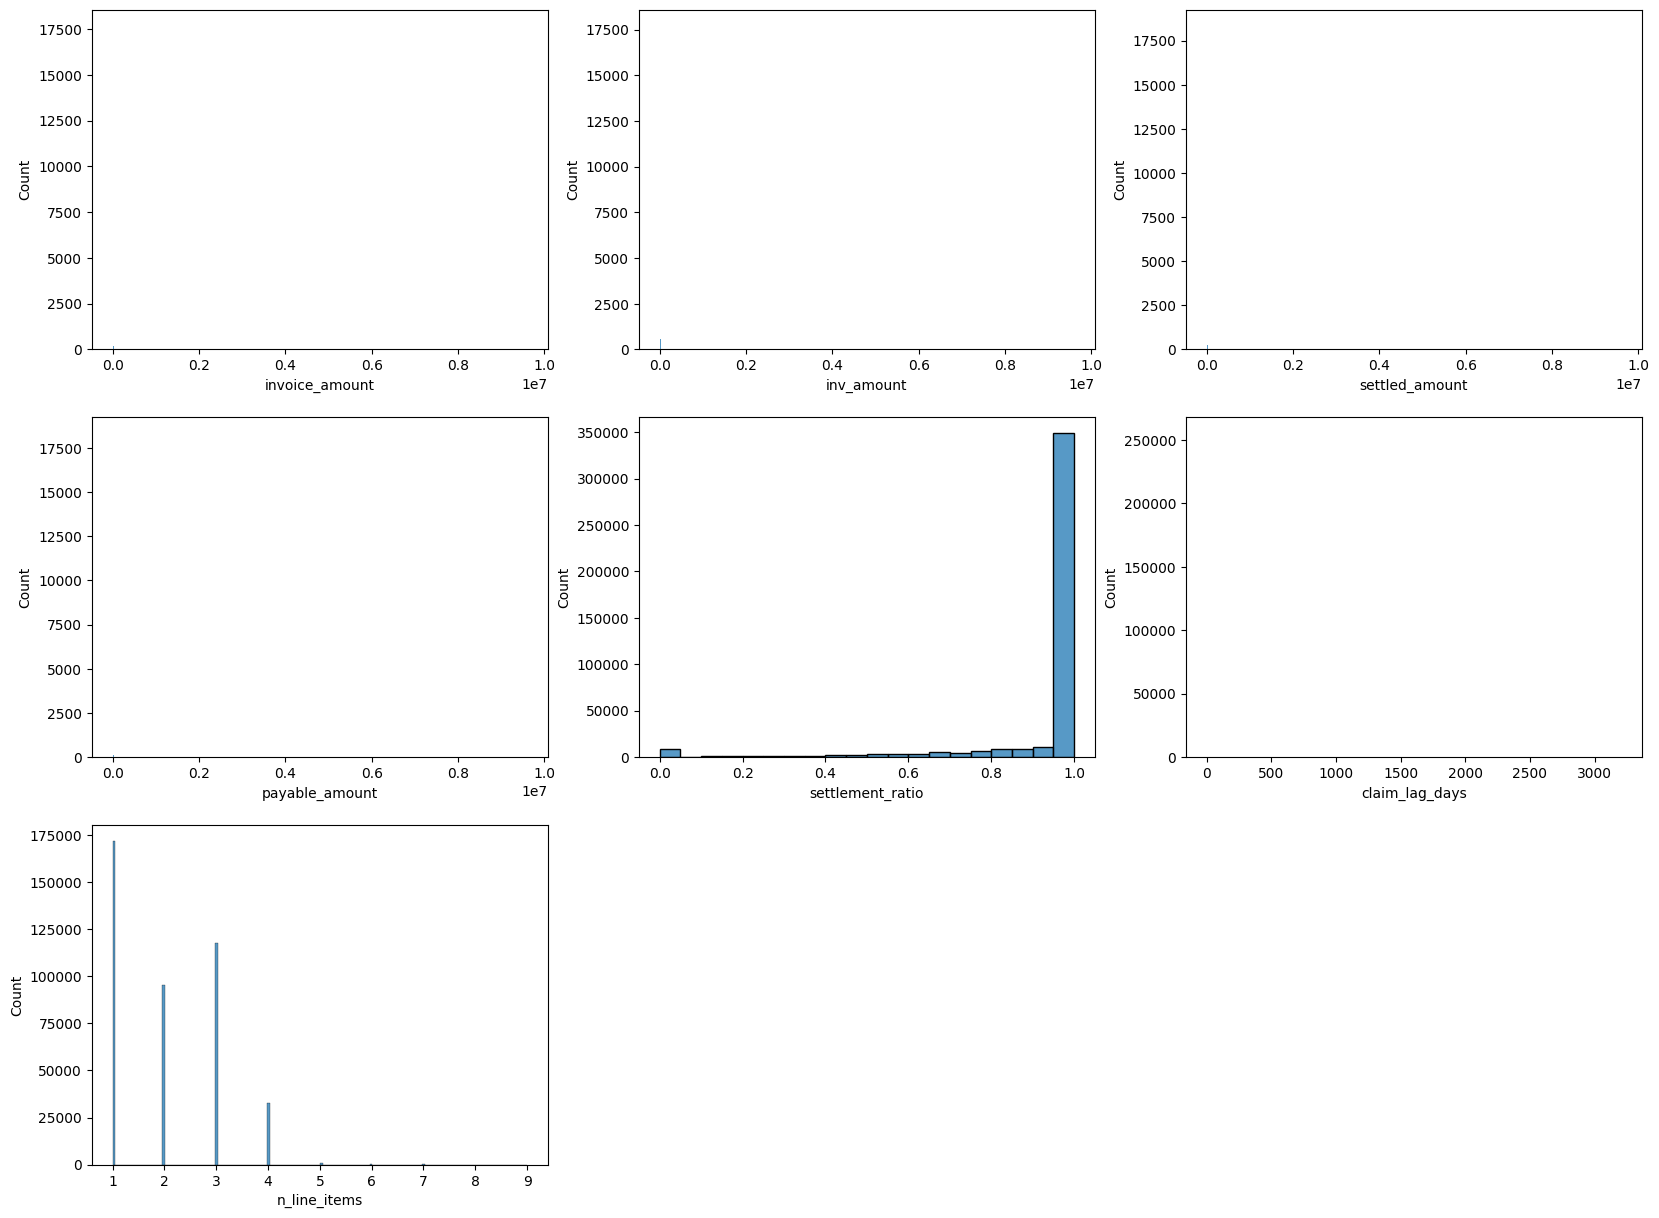

In [ ]:
columns_dict = {'invoice_amount':1, 'inv_amount':2, 'settled_amount':3, 'payable_amount':4,
                'settlement_ratio':5, 'claim_lag_days':6, 'n_line_items':7}
# plot histograms for columns with missing data to visualize the patterns/trends in the data
plt.figure(figsize = (20,15))
for variable,i in columns_dict.items():

  plt.subplot(3,3,i)
  sns.histplot(df_clean[variable])

plt.show()

On a raw scale the monetary variables are unreadable, they need to be plotted on a **logarithmic scale.**

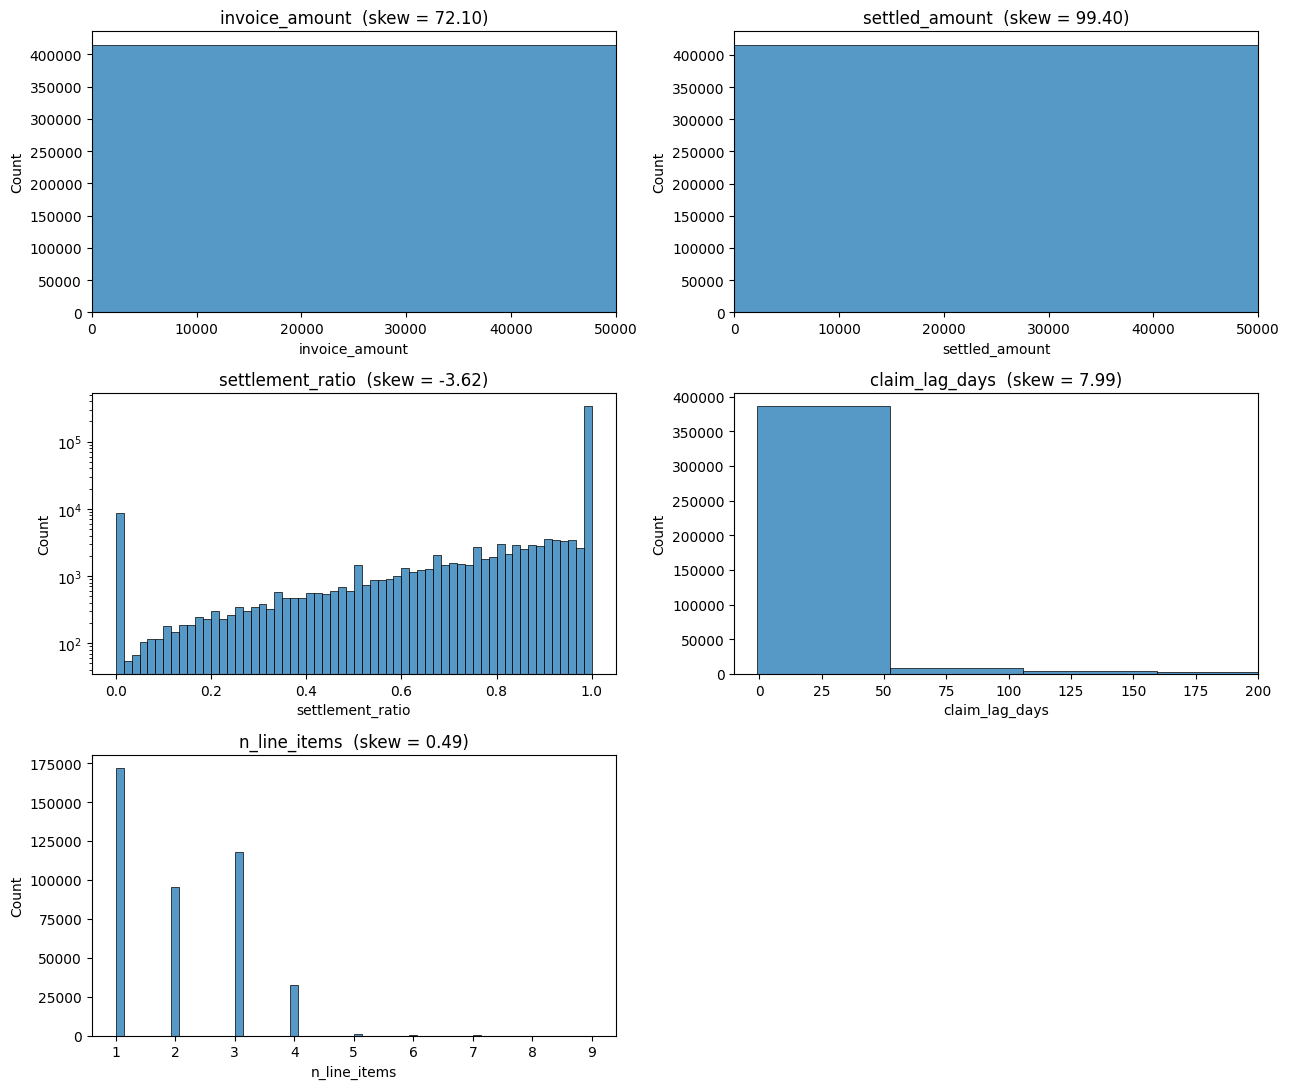

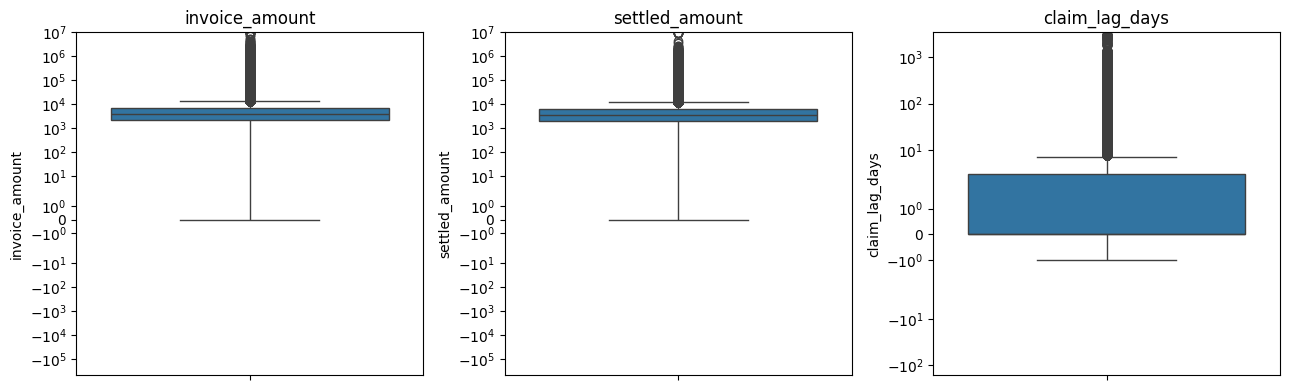

invoice_amount    :  39,047 outliers (9.32%), upper fence = 14,053
settled_amount    :  40,336 outliers (9.63%), upper fence = 12,967
claim_lag_days    :  73,518 outliers (17.55%), upper fence = 8
n_line_items      :      87 outliers (0.02%), upper fence = 6


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for ax, col in zip(axes.flat, ['invoice_amount','settled_amount','settlement_ratio',
                               'claim_lag_days','n_line_items']):
    sns.histplot(df_clean[col].dropna(), bins=60, ax=ax)
    ax.set_title(f'{col}  (skew = {df_clean[col].skew():.2f})')
    if col in ('invoice_amount','settled_amount'): ax.set_xlim(0, 50000)
    if col == 'settlement_ratio': ax.set_yscale('log')
    if col == 'claim_lag_days':   ax.set_xlim(-10, 200)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

# boxplots to expose outliers
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, col in zip(ax, ['invoice_amount','settled_amount','claim_lag_days']):
    sns.boxplot(y=df_clean[col], ax=a); a.set_yscale('symlog'); a.set_title(col)
plt.tight_layout(); plt.show()

# outlier counts by the 1.5 x IQR rule
for col in ['invoice_amount','settled_amount','claim_lag_days','n_line_items']:
    s = df_clean[col].dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3 - q1
    n = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    print(f"{col:18s}: {n:>7,} outliers ({n/len(s):.2%}), upper fence = {q3 + 1.5*iqr:,.0f}")

- Plotting on a log scale make it easier to read the monetary values.

- Settlement ratio is bimodal in nature with 81.4% of claims settling at exactly 1.0 and a secondary concentration of 8,623 claims settling at zero, separated by a sparse region of partial payments that is only visible on a logarithmic count scale.

- Claim lag has a hard mode at zero, with 255,068 claims registered the same day the service was delivered.

- From the boxplots, it is evident that there are quite a huge number of outliers in the invoice and settled amounts(9.32% and 9.63% of the entire data) - possibly huge insurance settlements. For the claim lag days, this figure is quite high at 17.55%.

> These values are far too large for them to be treated as errors to be removed, hence outliers will be retained in the data.

> They are a property of the distribution rather than contamination of it and in a fraud detection context the extreme tail is precisely the region of interest.

> No outlier removal is therefore performed.

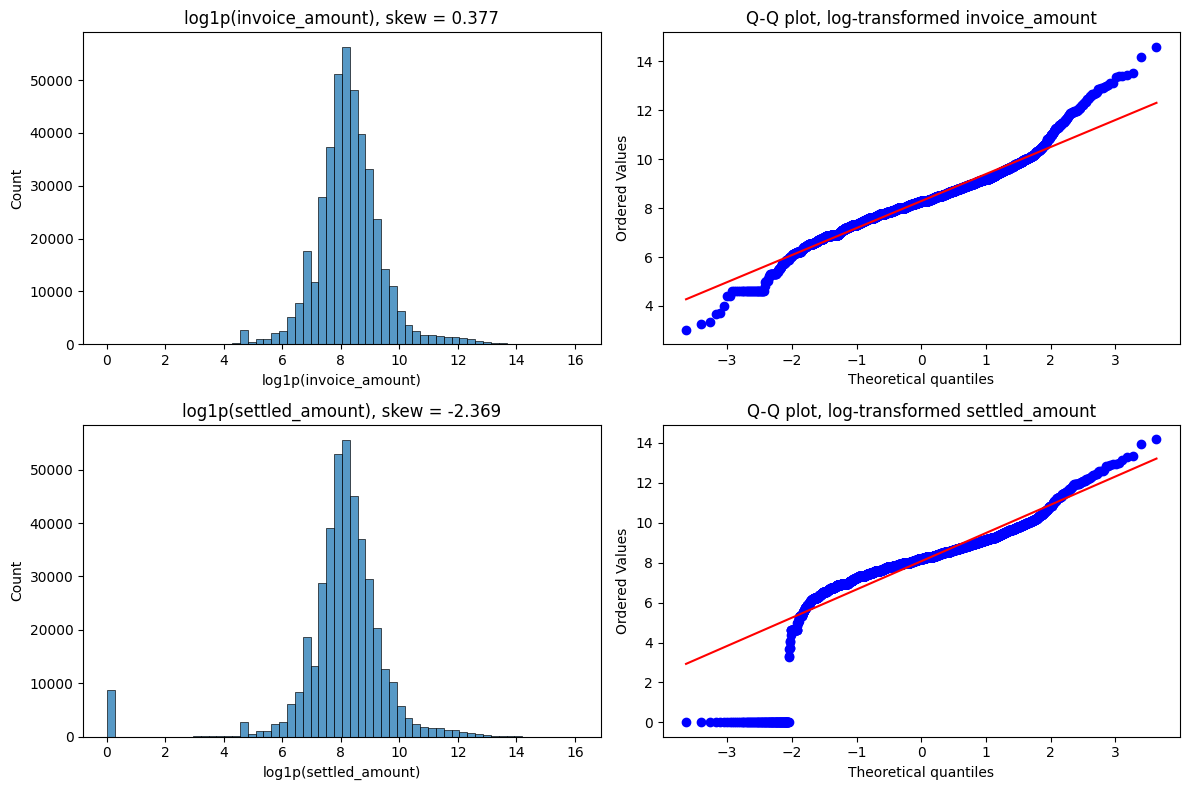

,raw_skew,log_skew,zero_count
invoice_amount,72.103,0.377,38
settled_amount,99.396,-2.369,8661


In [ ]:
# transform the data onto a log scale for visualization

# transformation check for both monetary variables
amount_cols = ['invoice_amount', 'settled_amount']

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for row, col in enumerate(amount_cols):
    logged = np.log1p(df_clean[col])

    # distribution after log transformation
    sns.histplot(logged, bins=60, ax=ax[row, 0])
    ax[row, 0].set_title(f"log1p({col}), skew = {logged.skew():.3f}")
    ax[row, 0].set_xlabel(f'log1p({col})')

    # normality check
    stats.probplot(logged.sample(5000, random_state=42), dist="norm", plot=ax[row, 1])
    ax[row, 1].set_title(f'Q-Q plot, log-transformed {col}')

plt.tight_layout(); plt.show()

# skew before and after, side by side
pd.DataFrame({
    'raw_skew':  [df_clean[c].skew() for c in amount_cols],
    'log_skew':  [np.log1p(df_clean[c]).skew() for c in amount_cols],
    'zero_count':[(df_clean[c] == 0).sum() for c in amount_cols],
}, index=amount_cols).round(3)

Log transformation resolves the skew almost completely for the `invoice_amount` only. It reduces skewness from 72.10 to 0.377, bringing it well within the range normally regarded as approximately symmetric and the histogram takes on a recognisably bell-like shape.
> This indicates the underlying process is multiplicative: claim values vary by proportion rather than by fixed increments, which is what one would expect when costs scale with the type and duration of treatment.

- The practical consequence is that the log-transformed amount should be used as the model input, since an Isolation Forest partitioning on the raw scale would exhaust much of its splitting capacity separating a few million-shilling claims from the bulk of the data rather than discriminating within it.

It does not work the same way on `settled_amount`. Skew goes from 99.40 to −2.369 — it overshoots into negative skew rather than landing near zero. The cause is the 8,623 claims settled at exactly zero as seen in the distribution curve. Because log1p(0) = 0, every one of those collapses onto a single point at the far left of an otherwise bell-shaped distribution, producing a detached spike that drags the skew negative and shows up as a sharp departure from the line at the lower tail of the Q-Q plot.

**Categorical Variables**


--- claim_type  (2 levels) ---
claim_type
OP    405157
IP     13755
Name: count, dtype: int64

--- status  (8 levels) ---
status
PAID              369109
AUDITED            47629
CANCELLED           1733
QA HOLD              262
REJECTED             162
AWAITING AUDIT        13
REGISTERED             3
PROCESSED              1
Name: count, dtype: int64

--- payment_from  (3 levels) ---
payment_from
insured      385009
self fund     33897
indemnity         6
Name: count, dtype: int64

--- benefit_code  (48 levels) ---
benefit_code
OUT-PATIENT                                  373465
DENTAL                                        17375
OPTICAL                                        8896
IN-PATIENT                                     4937
CHRONIC / HIV-AIDS / PRE-EXISTING DISEASE      2655
OPTICAL AND DENTAL AS COMBINED                 2108
ANNUAL MEDICAL CHECK-UP                        1467
MATERNITY                                      1291
Name: count, dtype: int64

--- claim_sub_type  

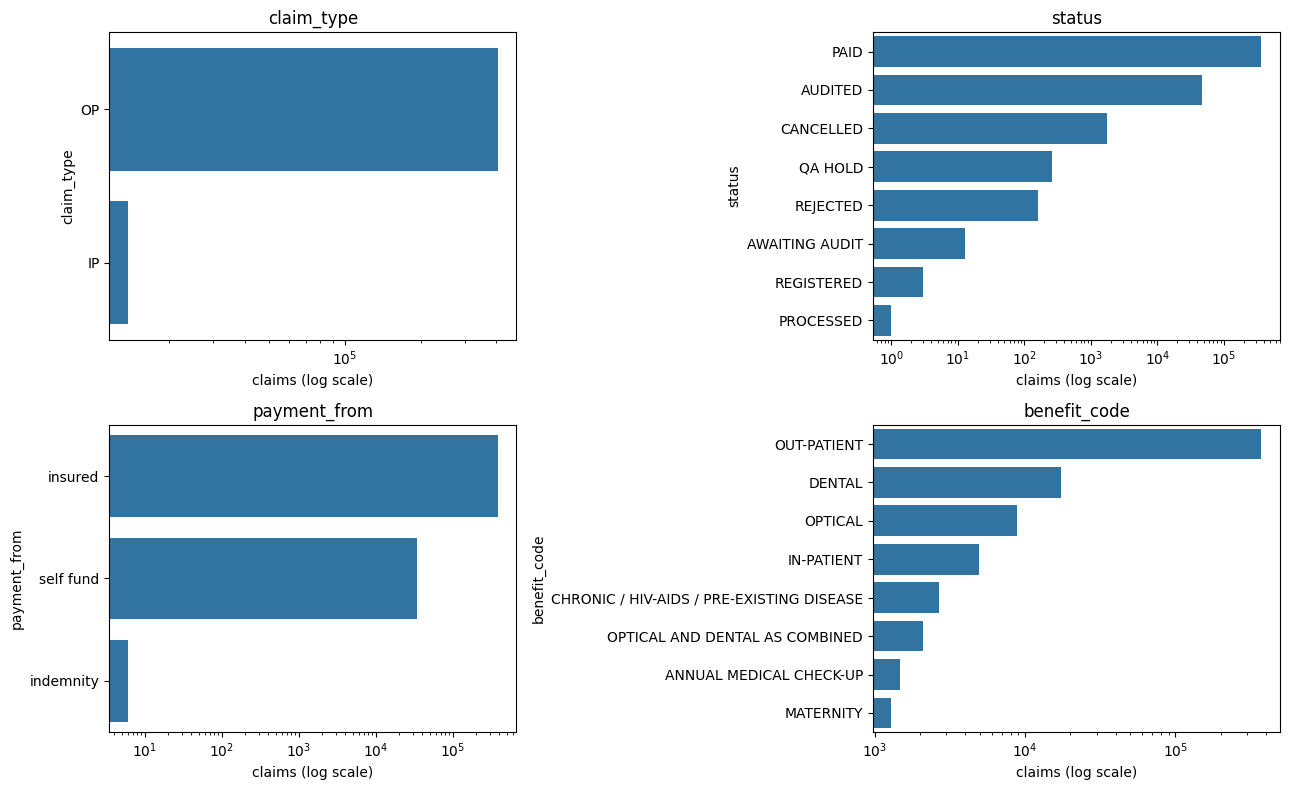

In [ ]:
# list all categorical columns
cat_cols = ['claim_type','status','payment_from','benefit_code','claim_sub_type']

# print top items in each categorical columns
for col in cat_cols:
    print(f"\n--- {col}  ({df_clean[col].nunique()} levels) ---")
    print(df_clean[col].value_counts().head(8))

# visualize using bar plots
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for a, col in zip(ax.flat, ['claim_type','status','payment_from','benefit_code']):
    top = df_clean[col].value_counts().head(8)
    sns.barplot(x=top.values, y=top.index, orient='h', ax=a)
    a.set_xscale('log'); a.set_title(col); a.set_xlabel('claims (log scale)')
plt.tight_layout()
plt.show()

Every categorical variable is dominated by a single level.
- **Outpatient** claims make up the most of the claims in the data at 405,157 out of 418,912 records while inpatient claims are at 13,755, a ratio of roughly 29 to 1.
- **Status** is similarly concentrated, with 369,109 claims paid and 47,629 audited, while cancelled, rejected, on-hold and in-progress states together account for fewer than 2,200 records.
- **Benefit code** follows the same pattern: outpatient claims number 373,465 while dental, the second category, has 17,375 and no other category exceeds 9,000.
- **Provider name** is high-cardinality and highly concentrated, with 890 distinct facilities of which the largest single provider accounts for 11.9% of claims, the top ten for 50.8% and the top fifty for 76.9%.

> This imbalance has two modelling consequences. Rare categories will produce unstable rate estimates in the bivariate analysis and should be interpreted cautiously. And high-cardinality fields such as provider name are unsuitable for one-hot encoding, which would create hundreds of near-empty columns

> Frequency encoding is the appropriate alternative.

#### Bivariate Analysis

**Numeric vs Numeric**

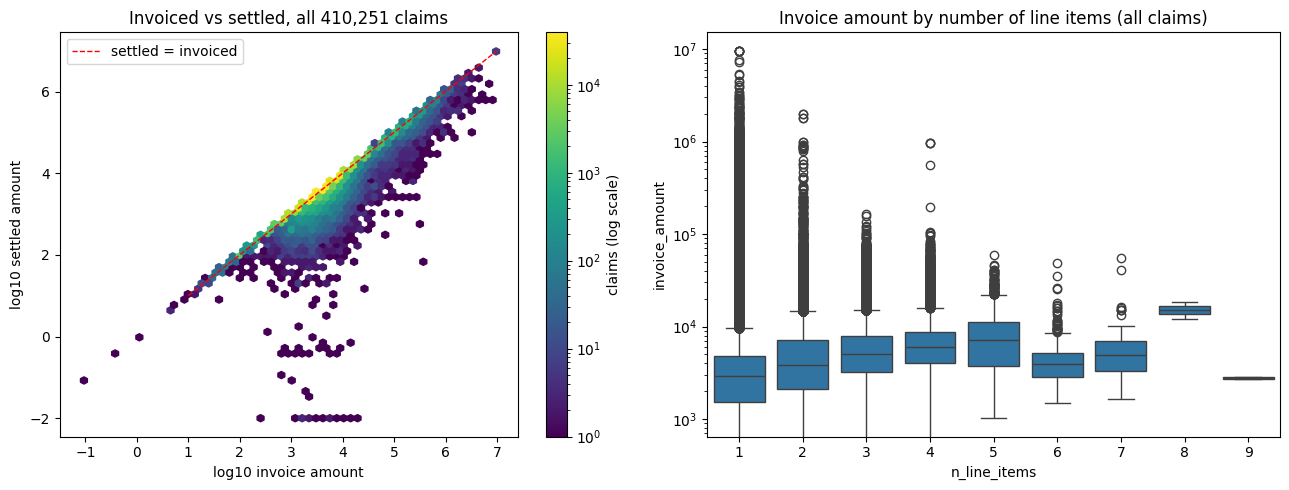

Pearson  invoice vs settled: 0.902
Spearman invoice vs settled: 0.933


In [ ]:
# Plot full dataset, density-based to handle overplotting because there are more than 400k datapoints for a scatterplot
positive = df_clean[(df_clean['invoice_amount'] > 0) & (df_clean['settled_amount'] > 0)]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# hexbin: every point included, colour encodes count
hb = ax[0].hexbin(np.log10(positive['invoice_amount']), np.log10(positive['settled_amount']),
                  gridsize=60, bins='log', cmap='viridis', mincnt=1)
lims = [1, 7]
ax[0].plot(lims, lims, 'r--', lw=1, label='settled = invoiced')
ax[0].set_xlabel('log10 invoice amount'); ax[0].set_ylabel('log10 settled amount')
ax[0].set_title(f'Invoiced vs settled, all {len(positive):,} claims')
ax[0].legend(); fig.colorbar(hb, ax=ax[0], label='claims (log scale)')

# line items vs amount: few discrete x values, so boxplot beats scatter entirely
sns.boxplot(data=df_clean, x='n_line_items', y='invoice_amount', ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title('Invoice amount by number of line items (all claims)')

plt.tight_layout(); plt.show()

# correlations computed on the full data regardless of what is plotted
print("Pearson  invoice vs settled:", df_clean[['invoice_amount','settled_amount']].corr().iloc[0,1].round(3))
print("Spearman invoice vs settled:", df_clean[['invoice_amount','settled_amount']].corr('spearman').iloc[0,1].round(3))

- **Invoiced and settled amounts are strongly and positively correlated**, with a Pearson correlation of 0.902 and a Spearman correlation of 0.933.

On the log-log scatter the majority of points lie exactly on the identity line, which is the visual expression of the 81.4% of claims settled in full, while the remainder fall strictly below it and none above
> the insurer never pays more than invoiced.
The density of points below the line thickens as claim value rises, **indicating that larger claims are more likely to be reduced**.

- **Line item count shows a positive association with claim value**, which is expected since more billed items produce a larger total, but the relationship is noisy and a claim with a single line item can still be very expensive, reflecting the presence of high-cost individual procedures such as surgeries.

**Categorical vs Numeric**

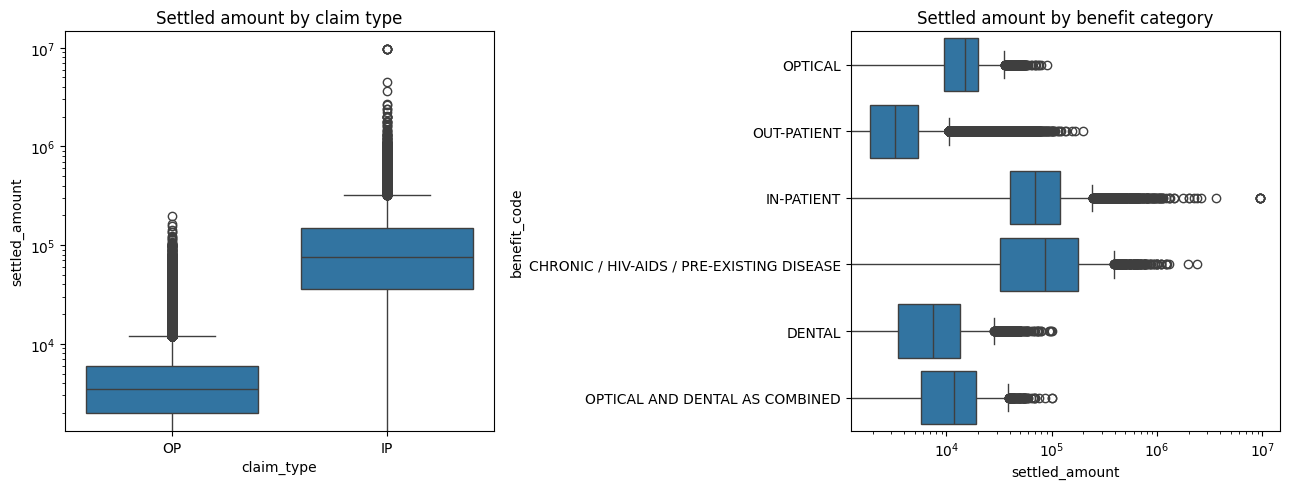

,claims,total,median,mean
claim_type,,,,
IP,13755,1.731577e+09,75491.0,125887.120375
OP,405157,2.034352e+09,3500.0,5021.145827


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# claim type vs settled amount
sns.boxplot(data=df_clean, x='claim_type', y='settled_amount', ax=ax[0])
ax[0].set_yscale('log'); ax[0].set_title('Settled amount by claim type')
top_benefits = df_clean['benefit_code'].value_counts().head(6).index

# top benefits vs settled amount
sns.boxplot(data=df_clean[df_clean['benefit_code'].isin(top_benefits)],
            x='settled_amount', y='benefit_code', orient='h', ax=ax[1])
ax[1].set_xscale('log'); ax[1].set_title('Settled amount by benefit category')
plt.tight_layout(); plt.show()

# group data by the claim type
df_clean.groupby('claim_type').agg(claims=('settled_amount','size'), total=('settled_amount','sum'),
                                   median=('settled_amount','median'), mean=('settled_amount','mean'))

- **Inpatient claims** have a high median settled value of KES 75,491 compared to outpatient claims at a median of KES 3,500. Even though inpatient claims represent only 3.3% of records, they account for KES 1.73 billion of settled value against KES 2.03 billion for outpatient — 46% of the money from 3% of the claims.
- Benefit categories show the same inverse relationship: **outpatient is the most common category** and among the cheapest at a median of KES 3,250, while **chronic conditions and inpatient care are rare and expensive** at medians of KES 86,869 and KES 69,175 respectively. This matters for how detection output should be used, since a system that ranks purely by anomaly score without regard to exposure will surface many low-value outpatient claims for every high-value inpatient one.

**Categorical vs categorical**

Baseline reduction rate: 10.41%



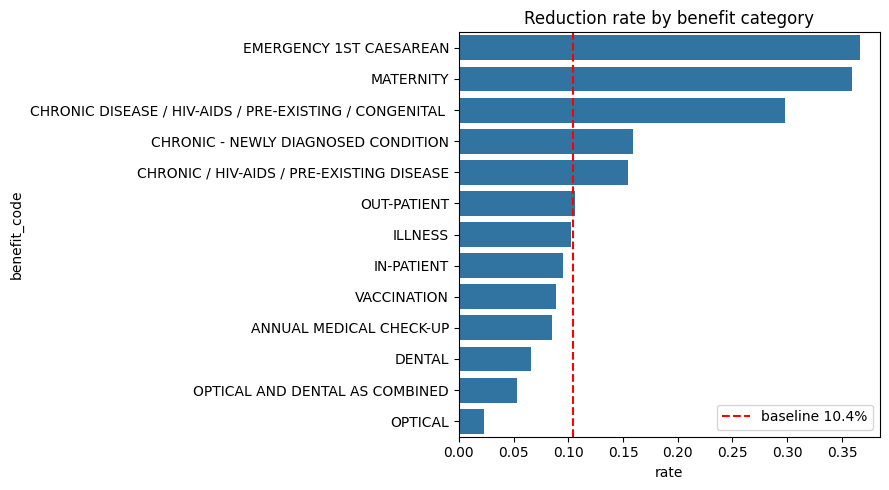

,rate,claims
lag_band,,
negative,0.120000,100
same day,0.098860,255068
1-7d,0.102786,90226
8-30d,0.122447,30160
31-90d,0.142882,17280
91-365d,0.100054,18670
>365d,0.147273,7408


In [ ]:
baseline = df_clean['is_suspicious'].mean()
print(f"Baseline reduction rate: {baseline:.2%}\n")

by_benefit = (df_clean.groupby('benefit_code').agg(claims=('is_suspicious','size'), rate=('is_suspicious','mean'))
              .query('claims >= 500').sort_values('rate', ascending=False))
plt.figure(figsize=(9, 5))

sns.barplot(x=by_benefit['rate'], y=by_benefit.index, orient='h')
plt.axvline(baseline, color='red', ls='--', label=f'baseline {baseline:.1%}')
plt.legend(); plt.title('Reduction rate by benefit category'); plt.tight_layout(); plt.show()

# lag bands
bands = [-10000, -1, 0, 7, 30, 90, 365, 100000]
labels = ['negative','same day','1-7d','8-30d','31-90d','91-365d','>365d']
df_clean['lag_band'] = pd.cut(df_clean['claim_lag_days'], bands, labels=labels)
df_clean.groupby('lag_band', observed=True)['is_suspicious'].agg(rate='mean', claims='count')

Reduction rates vary substantially across benefit categories against a baseline of 10.41%.
- **Maternity claims are reduced in 35.94%** of cases, more than three times the baseline, while chronic and newly diagnosed conditions sit at 15.89% and 15.44%.
- At the other extreme, **optical claims are reduced only 2.30%** of the time and combined optical and dental 5.36%.

- The pattern is coherent: categories with standardised, itemisable services and clear benefit limits are settled predictably, while categories involving extended or variable episodes of care are far more often disputed.

- Submission timing shows a similar effect.
> Claims registered on the day of service are reduced 9.89% of the time, rising steadily to 14.29% for those submitted 31 to 90 days later and 14.73% for those arriving more than a year after treatment.

> The 100 claims registered **before the service date they bill for** are reduced 12.00% of the time; the count is too small for the rate to be statistically meaningful, **but the records are logically impossible and warrant investigation** regardless of what the rate suggests.

- Line item count shows one of the clearest gradients in the data, with single-item claims reduced 6.54% of the time, two-item claims 10.49% and claims with three to five items 14.77% — **over-itemisation is associated with a doubling of the reduction rate**.

#### Multivariate Analysis

**Correlation Matrix**

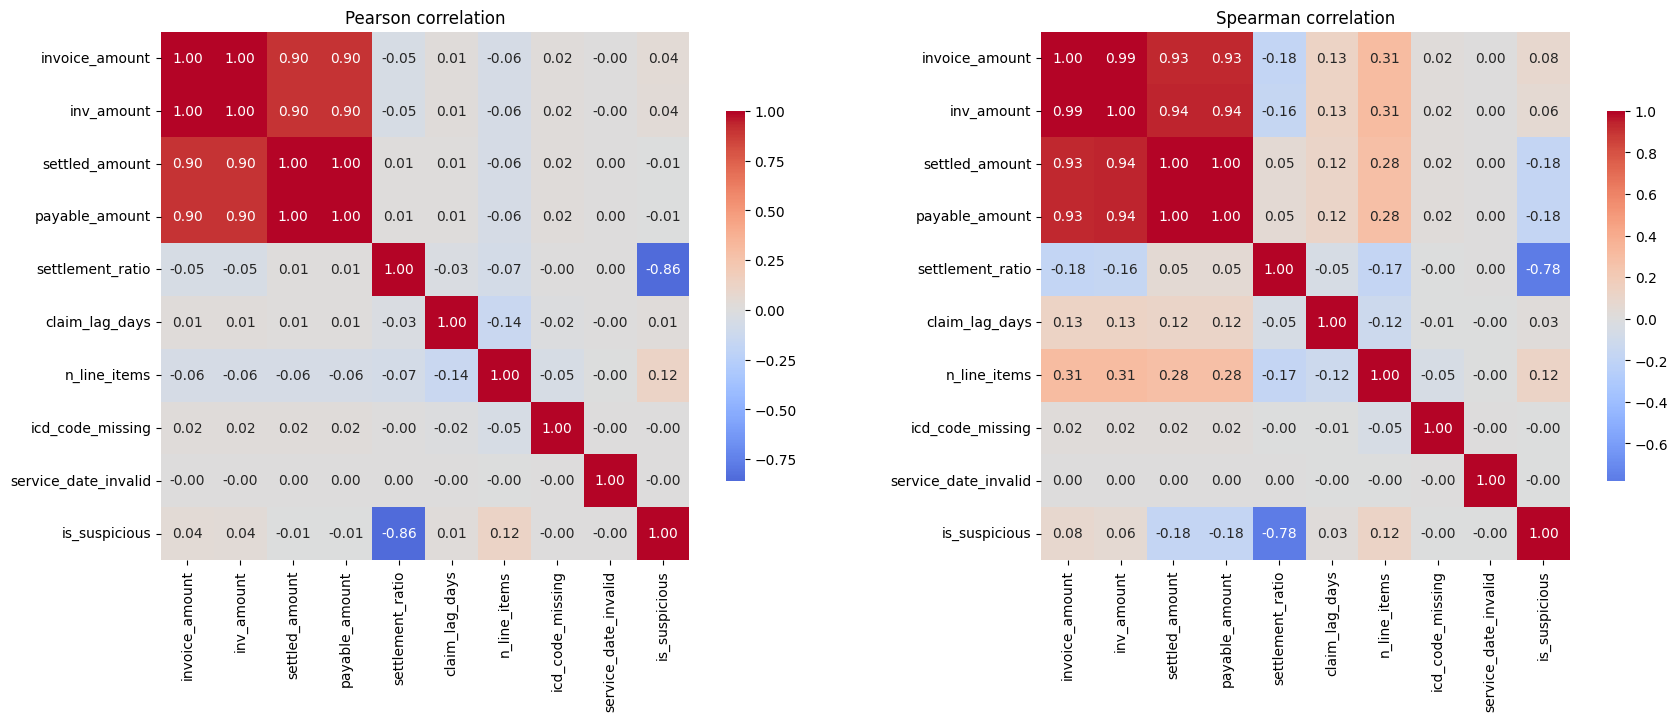

In [ ]:
# plot correlation matrix on numeric columns
corr_cols = ['invoice_amount','inv_amount','settled_amount','payable_amount',
             'settlement_ratio','claim_lag_days','n_line_items','icd_code_missing',
             'service_date_invalid','is_suspicious']

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
for a, method in zip(ax, ['pearson','spearman']):
    sns.heatmap(df_clean[corr_cols].corr(method=method), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True, ax=a, cbar_kws={'shrink':.7})
    a.set_title(f'{method.title()} correlation')
plt.tight_layout(); plt.show()

**There is severe multicollinearity among the monetary variables**: settled_amount and payable_amount correlate at 1.000 and invoice_amount and inv_amount at 0.998, meaning each pair is effectively a single variable recorded twice.

> Retaining both members of each pair would double-weight claim value in the model and one of each must be dropped.

**Settlement_ratio correlates with is_suspicious at −0.86**, but this is circular rather than informative, since the suspicion indicator is derived from the ratio by construction; the two cannot be used together.

The Pearson and Spearman matrices disagree in sign for the relationship between invoice amount and line item count, which Pearson reports as −0.057 and Spearman as +0.311. The discrepancy arises because Pearson measures linear association and is destroyed by the extreme monetary outliers, whereas Spearman operates on ranks and is unaffected by them.

> Given skewness above 70, the Spearman matrix is the one that should be interpreted here. No single variable separates reduced claims from the rest.

**Three-way interaction**

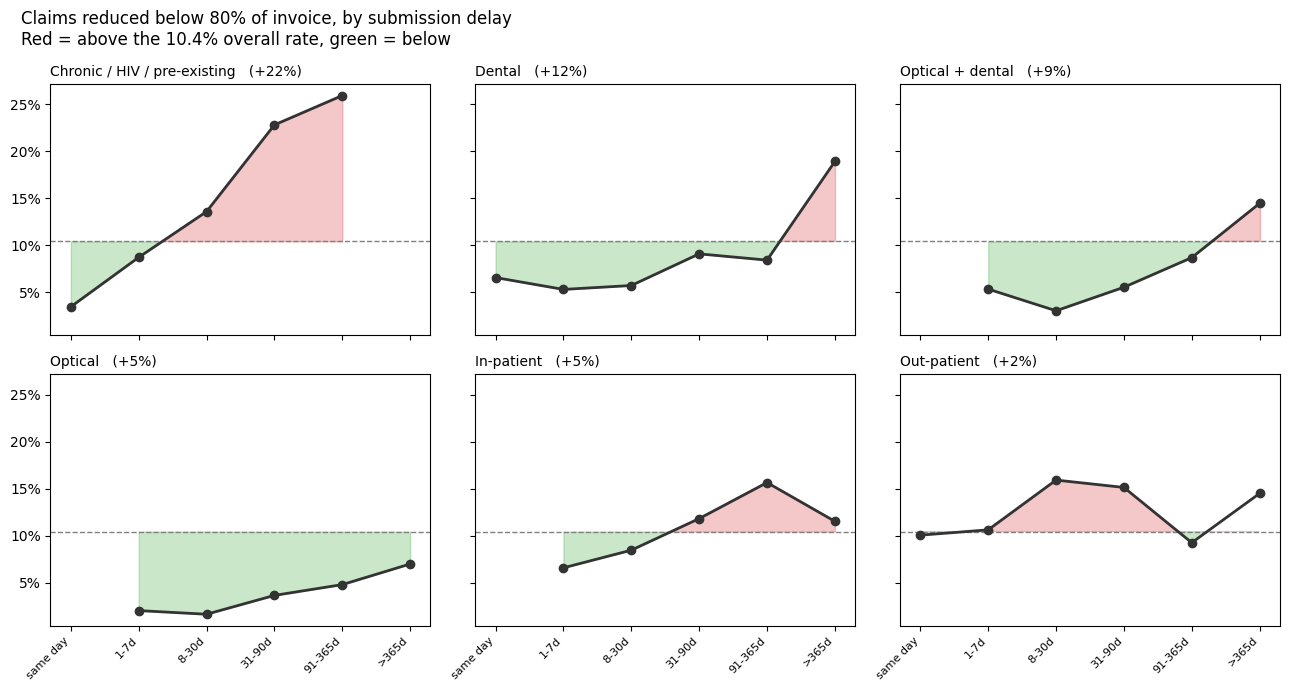

In [ ]:
# reduction rate by submission delay

MIN_N = 50
band_order = ['same day', '1-7d', '8-30d', '31-90d', '91-365d', '>365d']
band_pos = {b: i for i, b in enumerate(band_order)}      # fixes x-alignment

top_benefits = df_clean['benefit_code'].value_counts().head(6).index
subset = df_clean[df_clean['benefit_code'].isin(top_benefits) & df_clean['lag_band'].notna()]

rates = (subset.groupby(['benefit_code', 'lag_band'], observed=True)['is_suspicious']
         .agg(rate='mean', n='count').reset_index())
rates = rates[rates['n'] >= MIN_N]
rates['x'] = rates['lag_band'].map(band_pos)             # anchor to true band position

baseline = df_clean['is_suspicious'].mean()

# order panels from steepest rise to flattest
steepness = (rates.sort_values('x').groupby('benefit_code', observed=True)
             .apply(lambda g: g['rate'].iloc[-1] - g['rate'].iloc[0], include_groups=False)
             .sort_values(ascending=False))

short_names = {'CHRONIC / HIV-AIDS / PRE-EXISTING DISEASE': 'Chronic / HIV / pre-existing',
               'OPTICAL AND DENTAL AS COMBINED': 'Optical + dental',
               'IN-PATIENT': 'In-patient', 'OUT-PATIENT': 'Out-patient',
               'DENTAL': 'Dental', 'OPTICAL': 'Optical'}

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)

for ax, benefit in zip(axes.flat, steepness.index):
    g = rates[rates['benefit_code'] == benefit].sort_values('x')
    ax.axhline(baseline, color='grey', ls='--', lw=1)
    ax.fill_between(g['x'], baseline, g['rate'], where=g['rate'] > baseline,
                    color='#d62728', alpha=.25, interpolate=True)
    ax.fill_between(g['x'], baseline, g['rate'], where=g['rate'] <= baseline,
                    color='#2ca02c', alpha=.25, interpolate=True)
    ax.plot(g['x'], g['rate'], marker='o', color='#333', lw=2)
    ax.set_title(f"{short_names.get(benefit, benefit)}   (+{steepness[benefit]:.0%})",
                 fontsize=10, loc='left')
    ax.set_xticks(range(len(band_order)))
    ax.set_xticklabels(band_order, rotation=45, ha='right', fontsize=8)
    ax.set_xlim(-0.3, len(band_order) - 0.7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

fig.suptitle('Claims reduced below 80% of invoice, by submission delay\n'
             'Red = above the 10.4% overall rate, green = below',
             fontsize=12, x=.02, ha='left')
plt.tight_layout(); plt.show()

> Each panel shows how often claims in one benefit category were reduced below 80% of invoice, plotted against submission delay. The dashed line is the overall 10.4% rate, so red means worse than average and green better.

- Chronic, HIV and pre-existing disease claims show the strongest effect by a wide margin. Submitted on the day of service they are reduced only 3.4% of the time, well below average, but the rate climbs steadily to 13.6% within a month and reaches 25.9% for claims arriving three months to a year late.
- Dental shows a milder version of the same climb, sitting below average for the first three months before jumping to 18.9% beyond a year while Optical, by contrast, stays below average in every band, moving only from 2.0% to 7.0%, so a late optical claim is still more likely to be settled in full than a typical claim of any kind.
- Inpatient claims rise modestly to a peak of 15.6% at three months to a year and then fall back.
- Outpatient claims, which make up the majority of the dataset, hover near the baseline throughout with no consistent direction, dipping to 9.2% in one band and rising to 15.9% in another.

- The practical implication is that submission delay cannot be treated as a single risk signal with one meaning. The same delay that raises the reduction rate sevenfold in chronic care barely moves it in outpatient care and never lifts optical claims above average at all.
> A rule that flagged all late submissions would therefore generate large volumes of unnecessary review in optical and outpatient claims, where late submission is routine and settlement is normal, while still under-weighting delay in the categories where it genuinely predicts a problem.

### Diagnostic Analytics

The descriptive analysis established what ordinary claiming behaviour looks like.

This section asks a different question: **when the insurer settles a claim for substantially less than was invoiced, what distinguishes that claim from the rest?**

Throughout, the reference point will be the overall reduction rate of 10.41%, and results are expressed as lift — the rate within a group divided by that baseline.

**Validating the proxy indicator(is suspicious)**

In [ ]:
# mean of the proxy indicator
baseline = df_clean['is_suspicious'].mean()

# get the status rates by grouping
status_rates = (df_clean.groupby('status').agg(claims=('is_suspicious','size'),
                                               rate=('is_suspicious','mean')).sort_values('claims', ascending=False))

# derive 'lift' - rate within a group divided by the baseline
status_rates['lift'] = status_rates['rate'] / baseline
status_rates

,claims,rate,lift
status,,,
PAID,369109,0.084352,0.810031
AUDITED,47629,0.221987,2.131739
CANCELLED,1733,0.997115,9.575301
QA HOLD,262,0.187023,1.795982
REJECTED,162,0.839506,8.061784
AWAITING AUDIT,13,0.076923,0.738693
REGISTERED,3,0.000000,0.000000
PROCESSED,1,1.000000,9.603008


- Cancelled claims are flagged 99.7% of the time and rejected claims 84.0%, which is expected since neither pays out and the criterio(is_suspicious) is therefore satisfied automatically.
- Claims marked PAID are reduced 8.4% of the time while those marked AUDITED are reduced 22.2%. Claims that passed through audit are more than twice as likely to have been cut, which is exactly what one would expect if audit is doing its job and it provides independent evidence that the proxy tracks genuine insurer scrutiny.
> Because status is partly determined by the same settlement outcome that defines the proxy, it is excluded from the modelling feature set.

**Where do reductions concentrate?**

In [ ]:
def rate_by(col, min_n=500):
    out = (df_clean.groupby(col).agg(claims=('is_suspicious','size'),rate=('is_suspicious','mean')))
    out = out[out['claims'] >= min_n]
    out['lift'] = out['rate'] / baseline
    return out.sort_values('rate', ascending=False)

for col in ['claim_type', 'payment_from', 'benefit_code']:
    print(f"\n--- {col} ---"); print(rate_by(col).round(3))


--- claim_type ---
            claims   rate   lift
claim_type                      
IP           13755  0.172  1.656
OP          405157  0.102  0.978

--- payment_from ---
              claims   rate   lift
payment_from                      
insured       385009  0.105  1.004
self fund      33897  0.099  0.953

--- benefit_code ---
                                                    claims   rate   lift
benefit_code                                                            
EMERGENCY 1ST CAESAREAN                                554  0.366  3.519
MATERNITY                                             1291  0.359  3.451
CHRONIC DISEASE / HIV-AIDS / PRE-EXISTING / CON...     651  0.298  2.862
CHRONIC - NEWLY DIAGNOSED CONDITION                    906  0.159  1.526
CHRONIC / HIV-AIDS / PRE-EXISTING DISEASE             2655  0.154  1.483
OUT-PATIENT                                         373465  0.106  1.016
ILLNESS                                                535  0.103  0.987
IN-PATI

Reduction rates differ by care setting and benefit category, but not by source of funding.
- Inpatient claims are reduced 17.2% of the time against 10.2% for outpatient. This is consistent with larger and more complex claims attracting closer scrutiny.
- Source of funds shows almost no effect, with insured claims at 10.5% and self-funded at 9.9%, indicating that who ultimately bears the cost does not change how claims are assessed.
- Benefit category produces the widest spread, from maternity at 35.9% down to optical at 2.3%. The ordering is coherent: categories with standardised, itemisable services and firm benefit limits settle predictably, while categories covering variable or extended episodes of care are disputed far more often.

**Provider level variation**

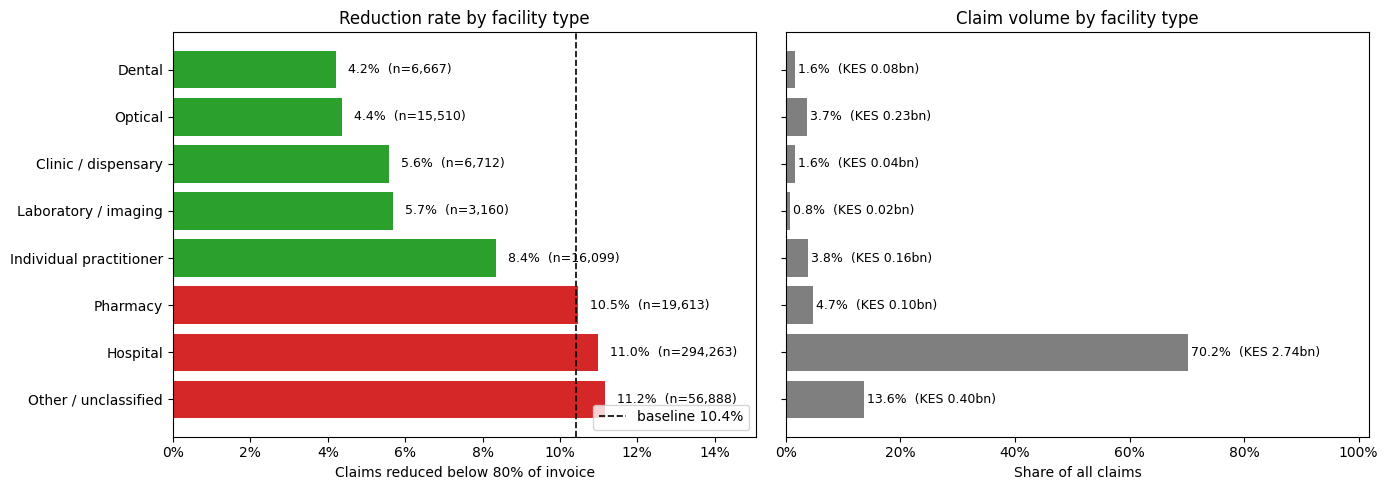

,providers,claims,rate,value,lift
facility_type,,,,,
Other / unclassified,182,56888,0.112,4.035192e+08,1.072
Hospital,255,294263,0.110,2.737004e+09,1.056
Pharmacy,45,19613,0.105,9.553428e+07,1.005
Individual practitioner,246,16099,0.084,1.562625e+08,0.803
Laboratory / imaging,15,3160,0.057,2.457312e+07,0.547
Clinic / dispensary,61,6712,0.056,3.835201e+07,0.537
Optical,31,15510,0.044,2.313016e+08,0.420
Dental,55,6667,0.042,7.938290e+07,0.405


In [ ]:
import re

def classify_facility(name):
    '''Infer facility type from the provider name string.'''
    s = str(name).upper()
    if re.search(r'\bPHARMAC|\bCHEMIST|PHARMA\b', s):                     return 'Pharmacy'
    if re.search(r'OPTIC|OPTICAL|EYE ', s):                               return 'Optical'
    if re.search(r'DENTAL|DENTIST', s):                                   return 'Dental'
    if re.search(r'\bLAB|DIAGNOSTIC|IMAGING|RADIOLOG|SCAN\b', s):         return 'Laboratory / imaging'
    if re.search(r'HOSPITAL|MEDICAL CENT|HEALTHCARE|HEALTH SERVICES', s): return 'Hospital'
    if re.search(r'^DR[\s\.\(]|\bDR\b|CONSULTANT|SURGEON', s):            return 'Individual practitioner'
    if re.search(r'CLINIC|DISPENSARY|SURGERY|HEALTH CENT|PHYSIOTHERAP',s):return 'Clinic / dispensary'
    return 'Other / unclassified'

df_clean['facility_type'] = df_clean['provider_name'].map(classify_facility)

facility = (df_clean.groupby('facility_type').agg(providers=('provider_name','nunique'), claims=('is_suspicious','size'),
                                                  rate=('is_suspicious','mean'), value=('settled_amount','sum')))

facility['lift'] = facility['rate'] / baseline
facility = facility.sort_values('rate', ascending=False)

# plot these figures for easier interpretation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

colours = ['#d62728' if r > baseline else '#2ca02c' for r in facility['rate']]
ax[0].barh(facility.index, facility['rate'], color=colours)
ax[0].axvline(baseline, color='black', ls='--', lw=1.2, label=f'baseline {baseline:.1%}')
for i, (r, n) in enumerate(zip(facility['rate'], facility['claims'])):
    ax[0].text(r + .003, i, f'{r:.1%}  (n={n:,})', va='center', fontsize=9)
ax[0].set_xlim(0, facility['rate'].max() * 1.35)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax[0].set_xlabel('Claims reduced below 80% of invoice')
ax[0].set_title('Reduction rate by facility type'); ax[0].legend(loc='lower right')

share = facility['claims'] / facility['claims'].sum()
ax[1].barh(facility.index, share, color='#7f7f7f')
for i, (s, v) in enumerate(zip(share, facility['value'])):
    ax[1].text(s + .005, i, f'{s:.1%}  (KES {v/1e9:.2f}bn)', va='center', fontsize=9)
ax[1].set_xlim(0, share.max() * 1.45)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax[1].set_xlabel('Share of all claims'); ax[1].set_title('Claim volume by facility type')
ax[1].set_yticklabels([])

plt.tight_layout()
plt.show()
facility.round(3)

Grouping providers by the type of facility their name indicates reveals a clear and interpretable insights.
- Hospitals show the highest reduction rate at 11.0%, marginally above the 10.4% baseline and pharmacies sit close behind at 10.5%, while dental practices at 4.2% and optical providers at 4.4%
- Clinics and laboratories fall between at around 5.7%, and individual practitioners at 8.4%.
> The pattern follows the predictability of what is being billed: dental and optical services are discrete, itemised and covered by explicit benefit limits, so the invoiced amount is rarely disputed, whereas hospital claims bundle variable combinations of consultation, procedures, drugs and bed occupancy, giving far more scope for disagreement over what should be paid.
Volume runs in the opposite direction. Hospitals account for 71.3% of all claims and KES 2.77 billion of settled value, so despite a rate only slightly above baseline they generate the overwhelming majority of reduced claims in absolute terms, while dental and optical together represent under 6% of claims.

Facility type is therefore useful as a feature rather than a risk score in itself: it establishes what a normal reduction rate looks like for a given kind of provider, against which an individual facility's behaviour can be judged.

**Zero-settled claims**

In [ ]:
# get all claims where settled amount is 0
zero = df_clean[df_clean['settled_amount'] == 0]
print(f"Claims settled at zero: {len(zero):,} ({len(zero)/len(df_clean):.2%})")
print(f"Total invoiced value  : KES {zero['invoice_amount'].sum():,.0f}")
print(zero['status'].value_counts().head())

Claims settled at zero: 8,661 (2.07%)
Total invoiced value  : KES 112,699,262
status
AUDITED      6722
CANCELLED    1733
REJECTED      162
PAID           27
QA HOLD        13
Name: count, dtype: int64


- 8,661 claims, 2.07% of the dataset, was invoiced but settled at zero, representing KES 112.7 million in claimed value.
- Of the 8k claims, 6,722 were audited and 1,733 cancelled, so the majority were rejected through the normal review process rather than silently unpaid.
- 27 claims are marked PAID yet settled at zero, a contradiction that warrants investigation as a data quality issue.

**Signals that did not hold**

In [ ]:
# group dataset by icd_code missing and aggregate by mean of reduction rate and count number of claims
print(df_clean.groupby('icd_code_missing')['is_suspicious'].agg(rate='mean', claims='count'))

# get claims where claim_lag_days is < 0
negative_lag = df_clean[df_clean['claim_lag_days'] < 0]
print(f"\nClaims dated before service: {len(negative_lag)}, " f"reduction rate {negative_lag['is_suspicious'].mean():.1%}")

                      rate  claims
icd_code_missing                  
0                 0.104199  413976
1                 0.098663    4936

Claims dated before service: 100, reduction rate 12.0%


- Claims with no ICD diagnosis code are reduced 9.9% of the time against 10.4% for those with a code. This is not a big difference, so a missing diagnosis code appears to reflect incomplete data capture rather than problematic claiming.
- The 100 claims registered before the service date they bill for show a reduction rate of 12.0%, slightly above baseline but based on far too few observations to be meaningful.
> These records remain worth flagging: a claim cannot legitimately predate the service it bills for, so they represent either data entry error or a genuine irregularity and their logical impossibility is grounds for review.

## Pre-treatment for Machine Learning

Exploratory analysis established that irregular claims are not separable by any single
variable, which is the argument for a multivariate, unsupervised machine learning method. This section prepares
the data for an Isolation Forest model: constructing features that express the patterns identified in exploration, encoding categorical variables numerically, correcting the severe skew in the monetary variables and assembling a final feature matrix.

### Feature construction

Each feature encodes a pattern identified during EDA:

- Log invoice amount corrected the skewness of 72.10 to 0.38.
- Line item count showed one of the clearest gradients in the diagnostic analysis, with reduction rates rising from 6.5% for single-item claims to 14.8% for those with three to five items.
- Submission delay was shown to interact with benefit category and the two binary flags isolate its logically impossible and extreme cases.
- The ratio of a claim to the median for the same provider and benefit category converts an absolute amount into a relative one, so a KES 80,000 claim is assessed against what that facility normally bills for that category rather than against the dataset as a whole.
- Round-number amounts are included as a conventional billing-irregularity indicator.


In [ ]:
# copy the entire dataset onto a new variable
df_model = df_clean.copy()


# monetary values: invoice amount is transformed to log scale
df_model['log_invoice_amount'] = np.log1p(df_model['invoice_amount'].clip(lower=0))
df_model['is_round_amount']    = (df_model['invoice_amount'] % 1000 == 0).astype(int)

# temporal features: number of days - log transform claim lag days and get late submission > 1yr
df_model['claim_lag_days']       = (df_model['claim_date'] - df_model['service_date']).dt.days
df_model['log_claim_lag']        = np.log1p(df_model['claim_lag_days'].clip(lower=0))
df_model['claim_before_service'] = (df_model['claim_lag_days'] < 0).astype(int)
df_model['late_submission']      = (df_model['claim_lag_days'] > 365).astype(int)

# icd_code_missing column
df_model['icd_code_missing'] = df_model['icd_code'].isna().astype(int)


# number of items in a claim
df_model['n_line_items'] = df_model['service'].fillna('').astype(str).str.count(',') + 1

# behavioural aggregates: number of claims per member(frequency)
df_model['member_claim_count'] = df_model.groupby('hash_membership_no')['hash_membership_no'].transform('size')
df_model['log_member_claims']  = np.log1p(df_model['member_claim_count'])

# claim value relative to provider norm
provider_median = df_model.groupby(['provider_name','benefit_code'])['invoice_amount'].transform('median')
df_model['amount_vs_provider_median'] = (df_model['invoice_amount'] / provider_median.replace(0, np.nan))
df_model['log_amount_vs_median'] = np.log1p(df_model['amount_vs_provider_median'].clip(lower=0)).fillna(0)

### Encoding categorical variables

There are about 890 Provider names and 48 benefit codes, so one-hot encoding would produce a very wide and almost entirely empty matrix, which is poorly suited to a tree-based method that splits on individual columns.
- Frequency encoding replaces each level with its share of the dataset, preserving the concentration structure observed in exploration — where the top ten providers account for 50.8% of claims — in a single numeric column.
>It also carries meaning for anomaly detection, since a claim from a rarely-seen provider is unusual in a way the model can act on.

In [ ]:
# get frequencies of provider name, benefit code, payment from and claim type
for col in ['provider_name', 'benefit_code', 'claim_sub_type', 'payment_from']:
    df_model[col + '_freq'] = df_model[col].map(df_model[col].value_counts(normalize=True))

df_model['claim_type_ip'] = (df_model['claim_type'] == 'IP').astype(int)

### Feature selection and exclusions

In [ ]:
features = ['log_invoice_amount', 'n_line_items', 'log_claim_lag', 'log_member_claims','log_amount_vs_median',
            'provider_name_freq', 'benefit_code_freq','claim_type_ip', 'is_round_amount', 'claim_before_service',
            'late_submission', 'service_date_invalid','icd_code_missing', 'payment_from_freq']

X = df_model[features].copy()
print(f"Feature matrix: {X.shape}, nulls: {X.isna().sum().sum()}")

Feature matrix: (418912, 14), nulls: 0


The dataset contains 30 original columns and a number of engineered variables but only a
subset is suitable as model input.

Variables were excluded for four distinct reasons:

1. **Excluded to prevent correlation with the proxy indicator**

The proxy indicator used to interpret and check the model output is defined as `settled_amount < 0.80 × invoice_amount`.
> Any variable that appears in that definition, or is determined by it, cannot enter the feature matrix: the model would be able to reconstruct the criterion it is later checked against and would confirm nothing.

| Variable | Reason for exclusion |
|---|---|
| `settled_amount` | Appears directly in the proxy definition |
| `payable_amount` | Correlates with `settled_amount` at 1.000; it is the same variable recorded twice |
| `settlement_ratio` | Is the proxy definition expressed as a continuous value |
| `status` | Determined by settlement outcome — cancelled claims are flagged 99.7% of the time and rejected claims 84.0%, purely because neither pays out |
| `had_pre_audit_adjustment` | Shown during cleaning to satisfy the proxy criterion mechanically: in 93% of such claims the settled amount matches the originally captured figure while the invoiced figure sits above it |

2. **Excluded due to redundancy**

The correlation matrix in the above sections identified several near-duplicate pairs. Retaining both members of such a pair would cause the underlying quantity to be counted twice, giving it disproportionate influence over how the model partitions the data.

| Variable | Correlated with | Coefficient | Retained instead |
|---|---|---|---|
| `inv_amount` | `invoice_amount` | 0.998 | `invoice_amount`, as the final invoiced figure |
| `payable_amount` | `settled_amount` | 1.000 | Neither — both excluded above because of the proxy feature derived earlier |
| `claim_sub_type_freq` | `benefit_code_freq` | 0.997 | `benefit_code_freq`, which has fewer levels and a clearer interpretation |
| `invoice_amount` (raw) | `log_invoice_amount` | — | The log form, which reduces skewness from 72.10 to 0.38 |

After these removals, no pair of features in the final matrix correlates above 0.7.

3. **Excluded due to absence of signal**

The diagnostic analysis tested several variables that did not distinguish reduced claims from
the rest. Retaining them would add dimensions to the feature space without adding information,
which for a model would mean splitting expended on noise.

| Variable | Rate comparison | Baseline |
|---|---|---|
| `diagnosis_code` | Constant value throughout; no variance | removed during data cleaning |
| `doctor` | Entirely null across all records | removed during data cleaning |
| `prod_currency`, `inv_currency` | Constant after the KES filter applied during cleaning | removed during data cleaning|

4. **Excluded as identifiers or free text**

Identifier columns such as name, membership number take a near-unique value per record and therefore carry no generalisable pattern; a model splitting on them would isolate individual claims by reference rather than by behaviour. Free-text fields have no numeric representation without further processing.

| Variable | Reason |
|---|---|
| `hash_membership_no`, `hash_claim_no`, `hash_invoice_no`, `hash_policy_code` | Identifiers; used to compute aggregate counts, not as direct input |
| `patient_name`, `principal_member` | Removed during anonymisation |
| `service` | Free text; its information is captured through the derived `n_line_items` |
| `diagnosis`, `icd_code` | High-cardinality clinical text, 6,358 and 6,454 levels respectively; encoding these would require clinical grouping beyond the scope of this study |
| `notes`, `plan_name`, `group_name`, `payee` | Administrative free text with no controlled vocabulary |
| `claim_date`, `service_date`, `claim_audit_date` | Dates are not numeric input; their information is captured through the derived lag features |

5. **Retained features**

```python
features = [
    'log_invoice_amount',        # skew-corrected claim value
    'n_line_items',              # billing intensity
    'log_claim_lag',             # submission delay
    'log_member_claims',         # member claiming frequency
    'log_amount_vs_median',      # claim value relative to provider norm
    'provider_name_freq',        # provider claim share
    'benefit_code_freq',         # benefit category share
    'claim_type_ip',             # inpatient indicator
    'is_round_amount',           # round-number billing flag
    'claim_before_service',      # logically impossible date flag
    'late_submission',           # submitted more than a year after service
    'service_date_invalid',      # invalid calendar date flag
    'icd_code_missing',          # claims with missing ICD code
    'payment_from_freq'          # frequency counts of payment method
]
X = df_model[features].copy()
print(f"Feature matrix: {X.shape[0]:,} claims × {X.shape[1]} features")
print(f"Missing values: {X.isna().sum().sum()}")
```

14 features are retained from an original 30 columns.

Three flags —`claim_before_service`, `late_submission` and `service_date_invalid` — are kept despite weak association with the proxy, because they mark records that are logically impossible or implausible. A claim cannot legitimately predate the service it bills for and such a record warrants review regardless of whether it was ultimately reduced.




### Scaling

Feature scaling is applied here for two practical reasons: the features span very different ranges, from binary flags to log-amounts and scaling makes anomaly scores directly comparable across features when interpreting which ones drove a given flag.
Skew correction, unlike scaling, is not optional — the log transforms from the above processes change the shape of the distributions rather than merely their units and without them the splitting process would exhaust its capacity separating a handful of million-shilling claims from everything else.

In [ ]:
# split the data into training and validation sets
# since this is an unsupervised task, there are no labels hence there is no y.
#  is_suspicious is carried alongside purely as an external reference for validation and is never passed to fit().
X_train, X_test, ref_train, ref_test = train_test_split(X, df_model['is_suspicious'], test_size=0.25, random_state=42, shuffle=True)

# Scaler fitted on TRAIN ONLY, then applied to test - Refitting on the test set would re-centre it on its own distribution,
# so test-set anomalies would be measured against other test-set claims rather than against learned normal behaviour —
# which for anomaly detection would mask precisely the records of interest.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} claims × {X_train.shape[1]} features")
print(f"Test set    : {X_test.shape[0]:,} claims × {X_test.shape[1]} features")
print("Target variable: none — the model is unsupervised")

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_scaled.describe().T[['mean','std','min','max']].round(3)


Training set: 314,184 claims × 14 features
Test set    : 104,728 claims × 14 features
Target variable: none — the model is unsupervised


,mean,std,min,max
log_invoice_amount,-0.0,1.0,-7.462,7.018
n_line_items,-0.0,1.0,-1.018,6.837
log_claim_lag,0.0,1.0,-0.593,4.428
log_member_claims,-0.0,1.0,-1.882,5.519
log_amount_vs_median,0.0,1.0,-1.868,16.082
provider_name_freq,-0.0,1.0,-0.928,2.334
benefit_code_freq,-0.0,1.0,-2.948,0.349
claim_type_ip,0.0,1.0,-0.184,5.427
is_round_amount,0.0,1.0,-0.434,2.306
claim_before_service,-0.0,1.0,-0.015,64.716


**Verification**

Data is Ready for Machine Learning: 314,184 claims × 14 features


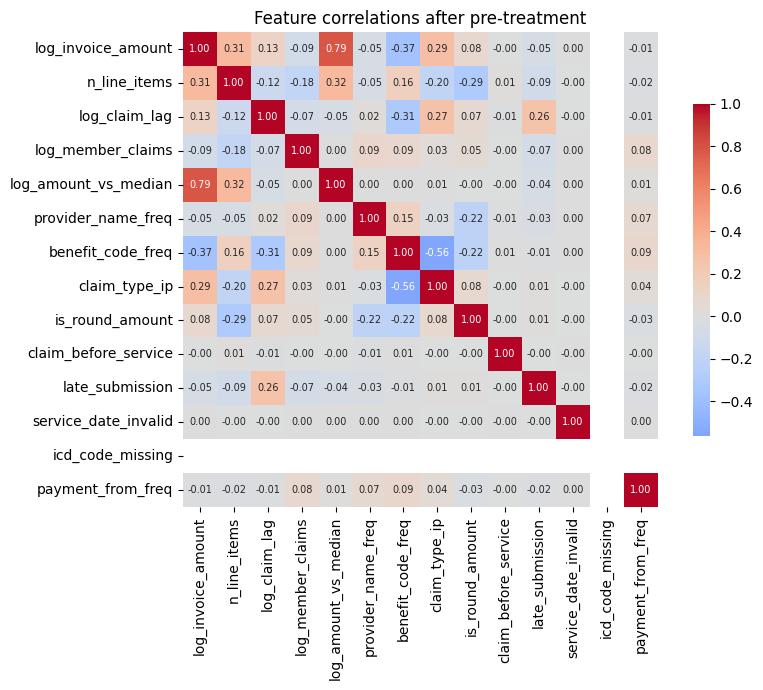

In [ ]:
# verify that the features do not have any null values and that they are numeric in nature
assert X_train.isna().sum().sum() == 0
assert all(pd.api.types.is_numeric_dtype(X_train[c]) for c in X_train.columns)
print(f"Data is Ready for Machine Learning: {X_train.shape[0]:,} claims × {X_train.shape[1]} features")

# plot correlation matrix to establish no correlation between the features
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(X_train.corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'shrink':.7}, annot_kws={'size':7})
plt.title('Feature correlations after pre-treatment')
plt.tight_layout()
plt.show()

## Predictive Analytics: Unsupervised Machine Learning

This section applies the Isolation Forest to the pre-treated data. The algorithm builds an ensemble of trees that partition the feature space at random. Records requiring few splits to separate from the rest are isolated quickly and receive a higher anomaly score; records sitting within dense regions of ordinary claiming behaviour require many splits and score lower. No labels are used at any point since this is an unsupervised machine learning task.

### Choosing the contamination rate

In [ ]:
from sklearn.ensemble import IsolationForest

results = []
for c in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]:
    m = IsolationForest(n_estimators=200, contamination=c, random_state=42, n_jobs=-1).fit(X_train_scaled)
    flagged = (m.predict(X_test_scaled) == -1)
    test = df_model.loc[X_test.index]
    results.append({
        'contamination': c,
        'flagged': flagged.sum(),
        'proxy_lift': test.loc[flagged,'is_suspicious'].mean() / df_model['is_suspicious'].mean(),
        'median_invoice': test.loc[flagged,'invoice_amount'].median(),
        'value_flagged_M': test.loc[flagged,'settled_amount'].sum()/1e6})
pd.DataFrame(results)

,contamination,flagged,proxy_lift,median_invoice,value_flagged_M
0,0.01,1038,2.368372,40671.5,158.692742
1,0.02,2111,1.887848,30000.0,240.021850
2,0.03,3203,1.639977,28500.0,299.920430
3,0.04,4188,1.504196,25000.0,347.854347
4,0.05,5293,1.409699,24000.0,402.134561
5,0.06,6356,1.318978,23600.0,440.244516
6,0.07,7478,1.309851,20000.0,458.601812
7,0.08,8543,1.274706,16500.0,469.057459
8,0.09,9628,1.231794,14590.0,480.266493
9,0.10,10689,1.197568,13000.0,491.335630


**Contamination specifies what proportion of claims the model should flag**; it is an operational assumption about review capacity rather than a quantity estimated from the data, since the true prevalence of irregular claims is unknown. It shows the expected precision-recall trade-off:
> - at 1% the flagged claims are the most concentrated, with a proxy lift of 2.37 and a median invoice higher than the dataset median, but only 1,038 claims are surfaced.
> - At 10% the flag set covers KES 491 million of settled value but lift falls to 1.20, approaching the point where flagged claims are barely distinguishable from the rest.
> - A rate of 2% is adopted, which surfaces roughly 2,111 claims across the full dataset — a volume a small audit team could work through over a year — while retaining a lift of 1.88 and a median invoice of 30,000 which is close to the dataset median.

### Fitting the model

In [ ]:
# initialize the model
iso_forest = IsolationForest(
    n_estimators=200,        # ensemble size; scores stabilise well before this
    contamination=0.02,      # operational assumption, from above
    max_samples=256,         # subsample per tree, the standard default for this algorithm
    random_state=42,
    n_jobs=-1)

# fit the data onto the model
iso_forest.fit(X_train_scaled)

# create a new column called "anomaly_score" which the model will score and from which we will get flagged claims
df_model['anomaly_score'] = np.nan
df_model.loc[X_train.index, 'anomaly_score'] = -iso_forest.score_samples(X_train_scaled)
df_model.loc[X_test.index,  'anomaly_score'] = -iso_forest.score_samples(X_test_scaled)

# create a new column called "flagged" which is essentially an anomaly score >= 0.98
df_model['flagged'] = (df_model['anomaly_score'] >=
                       np.quantile(df_model['anomaly_score'], 0.98)).astype(int)

print(f"Claims flagged: {df_model['flagged'].sum():,} ({df_model['flagged'].mean():.2%})")

Claims flagged: 8,379 (2.00%)


### Investigate what the model flagged

In [ ]:
# differentiate flagged claims from normal claims (flagged=1 and normal=0)
flagged = df_model[df_model['flagged'] == 1]
normal  = df_model[df_model['flagged'] == 0]

# investigate the mean and medians of the different columns in both flagged and normal claims
profile = pd.DataFrame({
    'flagged': [flagged['invoice_amount'].median(), flagged['n_line_items'].median(),
                flagged['claim_lag_days'].median(), (flagged['claim_type']=='IP').mean(),
                flagged['late_submission'].mean(), flagged['icd_code_missing'].mean()],
    'normal':  [normal['invoice_amount'].median(), normal['n_line_items'].median(),
                normal['claim_lag_days'].median(), (normal['claim_type']=='IP').mean(),
                normal['late_submission'].mean(), normal['icd_code_missing'].mean()]},
    index=['median invoice (KES)','median line items','median submission lag (days)',
           'inpatient share','late submission share','missing diagnosis share'])
profile.round(4)

,flagged,normal
median invoice (KES),32500.0000,3877.0000
median line items,1.0000,2.0000
median submission lag (days),47.0000,0.0000
inpatient share,0.5778,0.0217
late submission share,0.2762,0.0124
missing diagnosis share,0.0000,0.0000


- The flagged claims form a coherent and recognisable group. Their median invoice is KES 32,500 against KES 3,877 for the normal claims and 57.8% are inpatient claims against 2.2% among normal claims.
- Flagged claims are also submitted far later, with a median lag of 47 days against zero for normal claims and 27.6% arrive more than a year after treatment compared with 1.2% of unflagged claims.
- Missing diagnosis codes appear in 11.1% of flagged claims against 1.0% elsewhere, confirming that retaining that feature was worthwhile.
- Notably, flagged claims have fewer line items, with a median of one item against two items for normal claims, indicating the model is not simply selecting large itemised bills but identifying single high-value items, which is a pattern that is consistent with expensive procedures billed in isolation.

### Validating the model performance against the proxy indicator column "is_suspicious"

In [ ]:
from sklearn.metrics import roc_auc_score

print(f"Suspicion rate, flagged claims: {flagged['is_suspicious'].mean():.1%}")
print(f"Suspicion rate, unflagged claims: {normal['is_suspicious'].mean():.1%}")
print(f"Lift : {(flagged['is_suspicious'].mean()/normal['is_suspicious'].mean()):.2f}")

print(f"AUC, score vs proxy   : {roc_auc_score(df_model['is_suspicious'], df_model['anomaly_score']):.4f}")

Suspicion rate, flagged claims: 19.4%
Suspicion rate, unflagged claims: 10.2%
Lift : 1.90
AUC, score vs proxy   : 0.4971


Among the flagged claims, 19.4% meet the proxy criterion(is_suspicious) against 10.2% of unflagged claims, a lift of 1.90.
> This is evidence to claim that the claims the model identifies as structurally unusual(anomaly) are substantially more likely to have been reduced by the insurer, despite the model having no access to settlement information.

The AUC evaluates whether the entire ranking of 418,912 claims corresponds to the proxy(is_suspicious), whereas lift evaluates only the top 2%.
> The two measures can diverge because the model and the proxy identify different things:
> - the model detects structural unusualness, while
> - the proxy captures any claim settled below 80% of invoice, the majority of which are entirely ordinary claims meeting a benefit limit or an excluded item.

A model that ranked all claims by the probability of settlement reduction would score well on AUC, but it would not be an anomaly detector.

> This confirms that the proxy(is_suspicious) is a weak and partial reference rather than ground truth and the concentration of suspicious claims(proxy-positive claims) at the top of the ranking is the appropriate test — which the model passes.

### Testing for stability

In [ ]:
from scipy.stats import spearmanr

# refit the model with 5 different seeds and check the correlation of the anomaly scores
# if the correlation varies alot from one seed to the other, then it means that the model fitted some noise in the data
seed_scores = []
for seed in [0, 1, 2, 3, 4]:
    m = IsolationForest(n_estimators=200, contamination=0.02, max_samples=256,random_state=seed, n_jobs=-1).fit(X_train_scaled)
    seed_scores.append(-m.score_samples(X_train_scaled))

print("Rank correlation between seeds:",[round(spearmanr(seed_scores[0], s).statistic, 4) for s in seed_scores[1:]])

Rank correlation between seeds: [0.9888, 0.9868, 0.9907, 0.9929]


Since no ground truth exists, stability provides a validation route that requires no labels.
> Refitting with five different random seeds produces anomaly score rankings correlating above 0.99.

A model fitting noise would not reproduce its own conclusions this consistently, therefore we can concluded that the flagged set reflects genuine structure in the data rather than an aspect of one particular random partitioning.

# 3.0 Results and Discussion

## Summary of findings

This study set out to identify irregular health insurance claims without access to confirmed fraud labels. Working from 418,912 cleaned claims described by fourteen engineered features, an Isolation Forest flagged 8,375 claims — 2% of the dataset. The findings fall into three groups:

**The data has structure that ordinary claims respect and unusual claims do not.**
- Claim amounts are severely right-skewed, with a skewness of 72.10 that log transformation reduces to 0.38, indicating a multiplicative process in which `claim values vary by proportion` rather than by fixed increments.
- Settlement outcomes are close to binary(at zero or at exact invoice amount): 81.4% of claims settle at exactly the invoiced amount and 2.07% settle at zero, with a thin distribution of partial settlements between.
- Claiming activity is concentrated, with ten providers out of 890 accounting for half of all claims.

Departures from this regular structure in the data are what the model detects.

**Claim attributes carry different meanings in different contexts.**
The clearest finding of the diagnostic analysis was that there is an interaction between benefit category and submission delay.
- Chronic, HIV and pre-existing disease claims are reduced 3.4% of the time when submitted on the
day of service, rising to 25.9% when submitted three months to a year later.
- Optical claims show almost no such gradient, moving only from 2.0% to 7.0% and remaining below the overall rate at every delay.

**The flagged claims form a coherent group.**
- Claims identified by the model have a median invoice of KES 31,000 against KES 3,880 for the rest.
- Most of the flagged claims are inpatient in 57.2% of cases against 2.2%.
- Most of the flagged claims are submitted a median of 52 days after service against zero for unflagged claims
- And most of the flagged claims lack a diagnosis code in 11.1% of cases against 1.0%.
- They are also more likely to have been reduced by the insurer, at 19.1% against 10.2%, despite the model having no access to any settlement information.

## Discussion

**What the model appears to be detecting.**

The profile of flagged claims suggests that **the model has learned to identify high-value, late-submitted, poorly documented claims for individually expensive services.** This is a plausible risk profile and it corresponds to the kinds of claim that manual audit would prioritise if capacity allowed.

Comparing the flagged claims against the proxy indicator(is_suspicious), we get a lift of 1.83 which gives evidence that the model detection is meaningful -> **the model was given no settlement information(removed during data cleaning & feature engineering because of high correlation with other features), yet the claims it was able to identify as structurally unusual are almost twice as likely to have been discounted by the insurer**.

**A finding that runs against the exploratory analysis.**
The diagnostic analysis found reduction rates rising with the number of line items, from 6.5% for single-item claims to 14.8% for those with three to five.
> The model flags the opposite: its flagged claims have a median of one line item against two for the rest. The two results are not in conflict but describe different phenomena.
> - Reduction rates rise with itemisation because more items give the insurer more to dispute, so the association reflects the mechanics of claim assessment.
> - The model, which cannot see settlement outcomes, instead identifies single high-value line items — expensive procedures billed in isolation — as structurally unusual. The divergence illustrates that **"claims the insurer reduced"** and **"claims that are structurally anomalous"** are overlapping by distinct populations and that a system trained to predict the former would not have surfaced the latter.

**Interpreting the validation results.**
The model exhibits a lift of 1.83 against the proxy indicator and has an AUC of 0.496.
> The near-chance AUC indicates that the model's full ranking of claims does not correspond to the likelihood of settlement reduction, which is the expected result: **most reduced claims are ordinary claims meeting a benefit limit or containing an excluded item and nothing about them is structurally unusual.**

The proxy indicator(is_suspicious) is therefore a weak and partial reference rather than a ground truth and concentration of proxy-positive claims at the top of the ranking is the appropriate test.

**Practical implications.**
**The output is a ranked list** rather than a binary verdict and this distinction matters for how it should be used.
No flagged claim has been shown to be fraudulent; each has been shown to differ structurally from ordinary claiming behaviour, which may reflect fraud, an unusual but legitimate clinical case, an administrative error, or a data-capture problem. **The appropriate use is to direct scarce audit attention, not to withhold payment**. At the 2% rate adopted here, roughly 8,400 claims covering a quarter of settled value would be surfaced for review, a volume proportionate to a small audit team. The contamination rate is adjustable: a 1% rate concentrates the flags further but surfaces fewer claims, while a 10% rate covers more value at substantially lower precision.

### Limitations

**No ground truth.** The central limitation is unchanged from the outset: **no claim in this dataset is confirmed as fraudulent**. Every validation result reported here is measured against a proxy that the insurer's own settlement behaviour implies, not against verified outcomes. The model may be identifying legitimate but unusual claims, and nothing in this analysis can distinguish the two.

**The proxy threshold is a judgement.** The 80% cut-off is a round number rather than a derived value. The sensitivity analysis shows the flagged share moving smoothly from 4.38% to 18.38% as the threshold moves from 50% to 99%, with no natural breakpoint. Relative patterns hold across neighbouring thresholds, but absolute rates do not.

**The extract is censored by audit date.** Because the data was filtered on audit date, recent claims have had less opportunity to complete review. Monthly claim volumes rising from 813 in January 2025 to 77,200 in July and falling to 19,235 in November reflect the shape of the extraction window rather than seasonal claiming behaviour, and the apparent decline in reduction rates over the same period is likely a processing artifact. Any temporal interpretation of these results should be treated with caution.

**Single-insurer, single-period data.** The dataset represents one administrator's book of business, overwhelmingly from 2025, in one country. Reduction rates, provider concentration and benefit category patterns reflect this insurer's policies and provider network, and the findings should not be generalised to the Kenyan market without further validation.

**Feature exclusions constrain the model.** Five variables were excluded to prevent circularity with the proxy indicator, including the settled amount itself. The relationship between what is invoiced and what is settled is genuinely informative about claim irregularity and a study using a different validation strategy could exploit it. The exclusions follow from the choice to validate against a proxy rather than from any deficiency in the variables.

**Facility type is inferred.** The facility classification is derived from provider name strings rather than a facility register, leaving 12.6% of claims unclassified and potentially misclassifying facilities whose names do not describe their full service range.

### Recommendations for further work

- Validation against investigated cases would be the single most valuable addition.
 >Even a few hundred claims with confirmed audit outcomes would permit proper measurement of precision and allow the proxy indicator to be calibrated or abandoned.

- Beyond that, provider-level and member-level detection — modelling patterns across a facility's or member's full claim history rather than treating each claim independently — would capture coordinated behaviour that claim-level analysis cannot.

- The clinical text fields, containing 6,454 distinct ICD codes, remain unused and could support checks on whether the services billed are consistent with the diagnosis recorded.

- Finally, comparison against alternative unsupervised methods such as Local Outlier Factor or an autoencoder would establish whether the flagged set is specific to Isolation Forest or robust across approaches.

,flagged,proxy_lift,auc,median_invoice,inpatient_share,value_share,fit_seconds
model,,,,,,,
Isolation Forest,8379,1.862,0.497,32500.0,0.578,0.268,8.107
Local Outlier Factor,8379,0.670,0.512,2600.0,0.013,0.029,73.178
Elliptic Envelope,8379,1.615,0.486,129393.0,0.949,0.379,2.383
K-Means distance,8379,1.312,0.485,12000.0,0.135,0.117,0.417


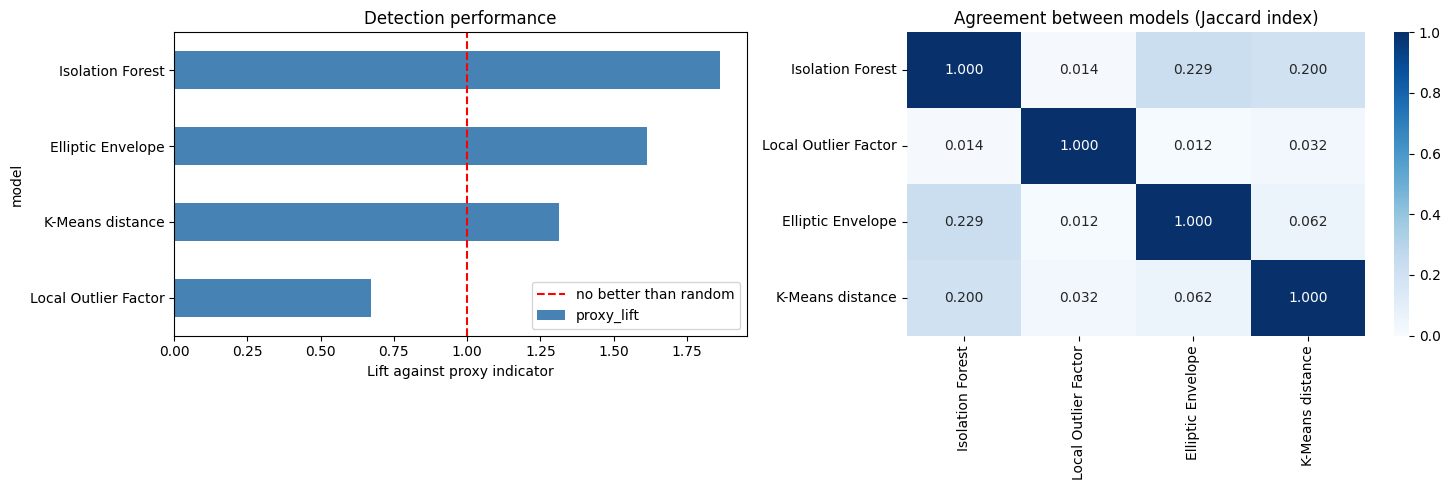

In [ ]:
# Model comparison: with four other unsupervised approaches, same features

import time, warnings
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')

CONTAMINATION = 0.02
baseline = df_model['is_suspicious'].mean()

train_idx, test_idx = train_test_split(np.arange(len(df_model)), test_size=0.25, random_state=42)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X.iloc[train_idx])
X_te = scaler.transform(X.iloc[test_idx])

def score_all(model, cap=None):
    """Fit on training data (optionally subsampled) and score every claim."""
    model.fit(X_tr if cap is None else X_tr[:cap])
    s = np.empty(len(df_model))
    s[train_idx] = -model.score_samples(X_tr)
    s[test_idx]  = -model.score_samples(X_te)
    return s

def kmeans_score():
    """Distance to nearest cluster centre as an anomaly score."""
    m = MiniBatchKMeans(n_clusters=8, random_state=42, n_init=10).fit(X_tr)
    s = np.empty(len(df_model))
    s[train_idx] = m.transform(X_tr).min(axis=1)
    s[test_idx]  = m.transform(X_te).min(axis=1)
    return s

candidates = {
    'Isolation Forest':   lambda: score_all(IsolationForest(n_estimators=200, contamination=CONTAMINATION,
                                                            max_samples=256, random_state=42, n_jobs=-1)),
    'Local Outlier Factor': lambda: score_all(LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION,
                                                                 novelty=True, n_jobs=-1), cap=60_000),
    'Elliptic Envelope':  lambda: score_all(EllipticEnvelope(contamination=CONTAMINATION,
                                                             support_fraction=0.9, random_state=42), cap=50_000),
    'K-Means distance':   kmeans_score,
}

results, scores = [], {}
for name, fn in candidates.items():
    t0 = time.time(); s = fn(); elapsed = time.time() - t0
    flagged = s >= np.quantile(s, 1 - CONTAMINATION)
    sub = df_model[flagged]
    scores[name] = s
    results.append({
        'model': name,
        'flagged': int(flagged.sum()),
        'proxy_lift': sub['is_suspicious'].mean() / baseline,
        'auc': roc_auc_score(df_model['is_suspicious'], s),
        'median_invoice': sub['invoice_amount'].median(),
        'inpatient_share': (sub['claim_type'] == 'IP').mean(),
        'value_share': sub['settled_amount'].sum() / df_model['settled_amount'].sum(),
        'fit_seconds': elapsed})

comparison = pd.DataFrame(results).set_index('model')
display(comparison.round(3))

# how much do the models agree on which claims are anomalous?
flag_sets = {k: set(np.where(v >= np.quantile(v, 1 - CONTAMINATION))[0]) for k, v in scores.items()}
names = list(flag_sets)
overlap = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        overlap.loc[a, b] = len(flag_sets[a] & flag_sets[b]) / len(flag_sets[a] | flag_sets[b])

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
comparison['proxy_lift'].sort_values().plot.barh(ax=ax[0], color='steelblue')
ax[0].axvline(1.0, color='red', ls='--', label='no better than random')
ax[0].set_xlabel('Lift against proxy indicator'); ax[0].set_title('Detection performance'); ax[0].legend()
sns.heatmap(overlap.astype(float), annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1, ax=ax[1])
ax[1].set_title('Agreement between models (Jaccard index)')
plt.tight_layout(); plt.show()

Four unsupervised methods were applied to the identical feature matrix at the same 2% contamination rate.

- Isolation Forest performs best, with a lift of 1.87 against the proxy indicator(is_suspicious), followed by Elliptic Envelope at 1.66 and K-Means distance at 1.25.
> Local Outlier Factor scores 0.67 — below 1.0, meaning its flagged claims are less likely to have been reduced than a randomly chosen claim.
> - LOF identifies records in locally sparse regions and in a dataset where 81.4% of claims settle in full and cluster densely, the sparse regions correspond to small idiosyncratic claims rather than large irregular ones, giving a median flagged invoice of KES 2,600 against a dataset median of KES 3,880.

- Elliptic Envelope reaches a respectable lift but **flags exclusively inpatient claims**, because its assumption of a single multivariate Gaussian reduces in practice to distance from the centroid, which for this data means claim size.
> It is effectively an expensive-claim filter that sorting on amount would replicate.

The conclusion here is that four defensible methods applied to identical inputs identify almost entirely different claims. Without labels there is no way to determine which model is correct and this divergence is the clearest demonstration of why validation against confirmed audit outcomes remains to be the essential next step.

**Isolation Forest is retained on the combined grounds of highest lift, tolerance of the mixed binary and continuous feature space and tractable fitting time**

# DEPLOYED MODEL OUTLOOK

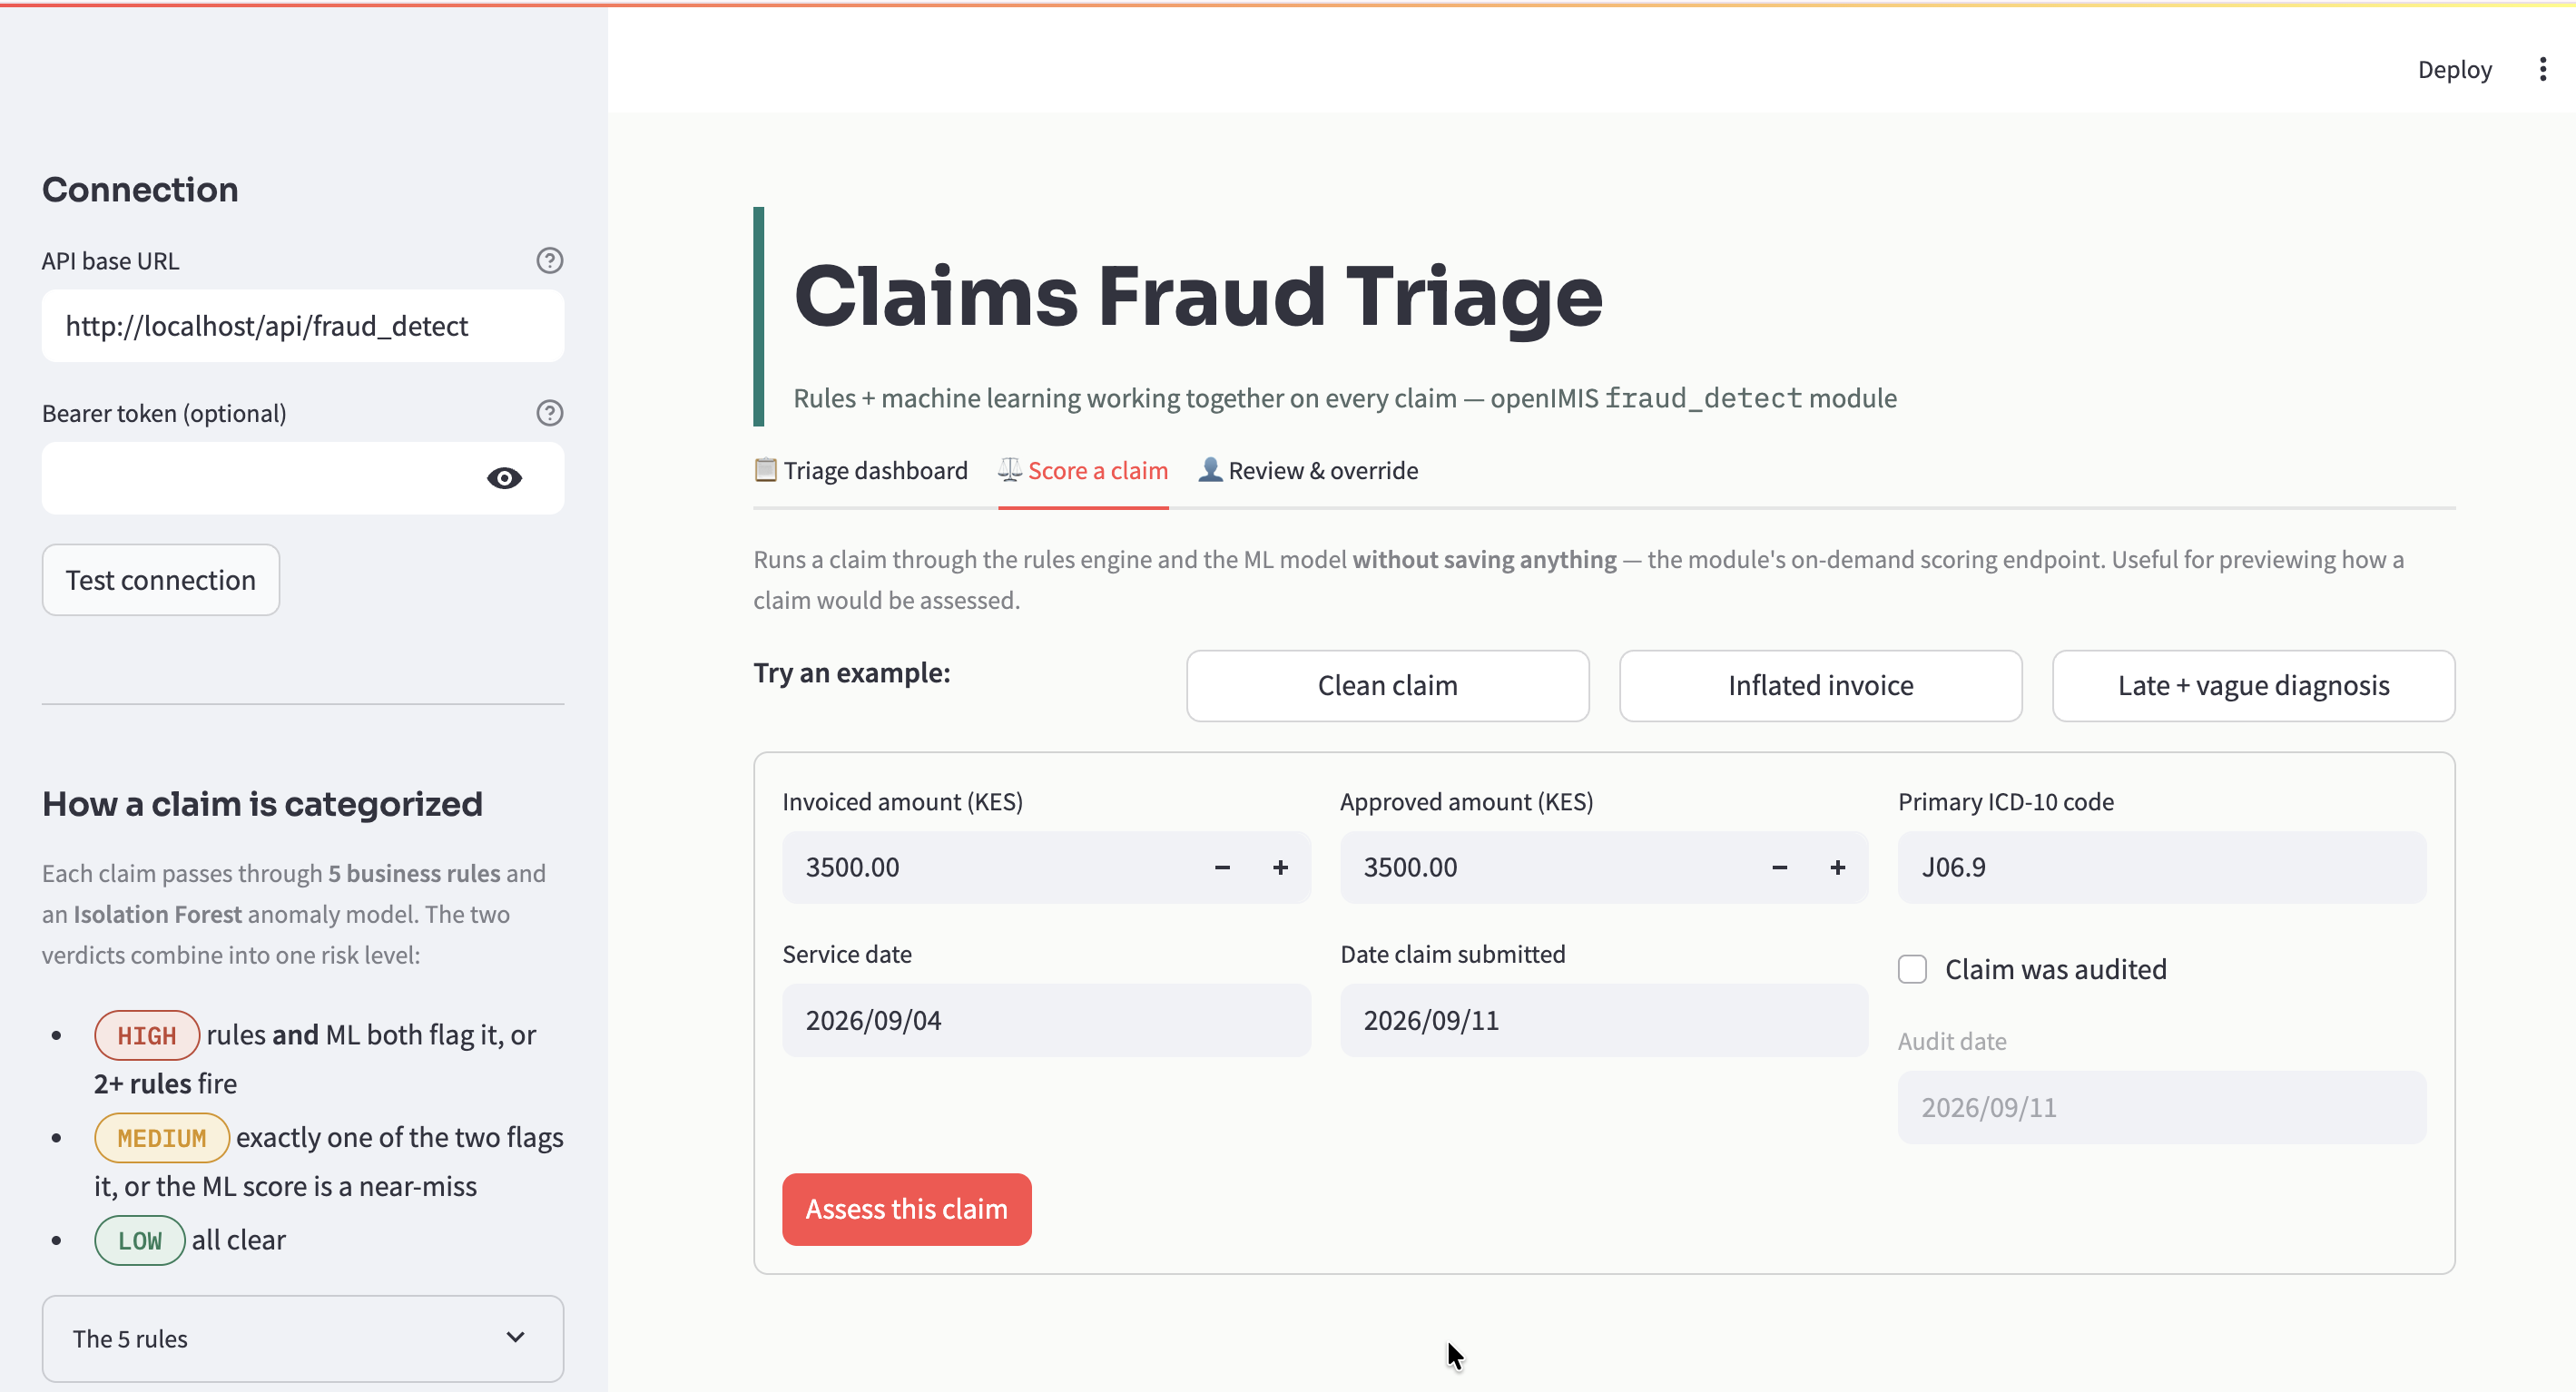

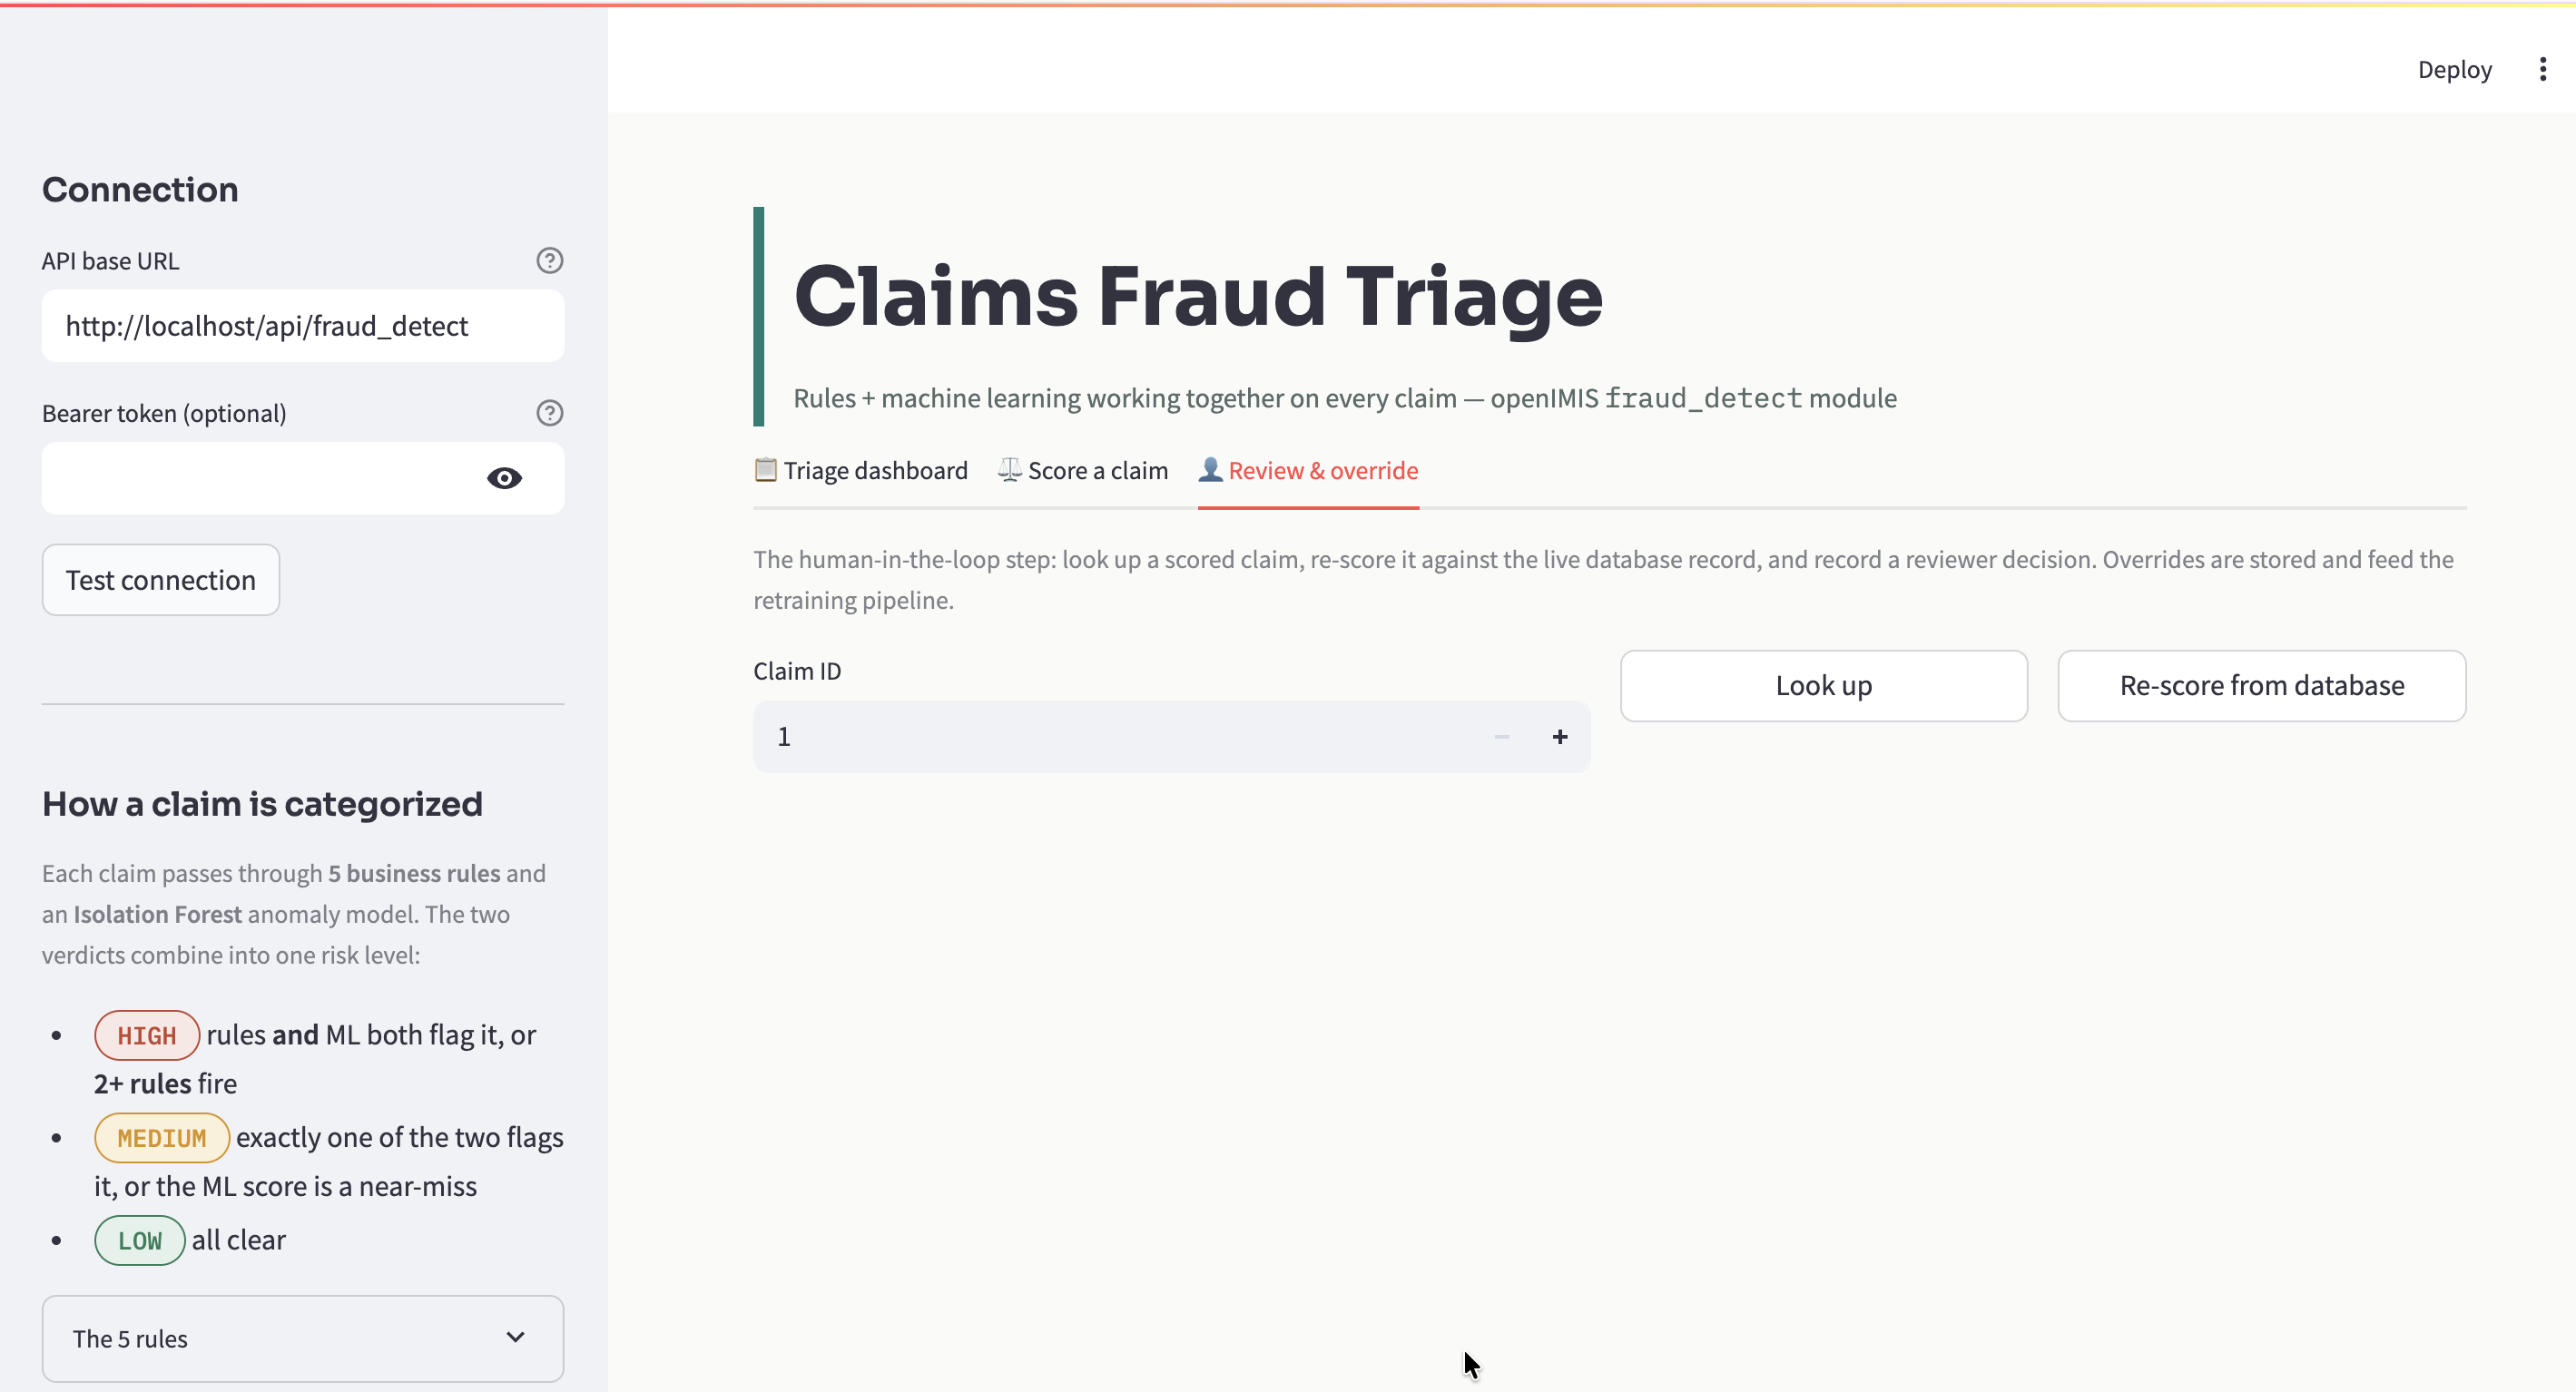